In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

root_str = str(PROJECT_ROOT)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

#print("PROJECT_ROOT =", PROJECT_ROOT)
#print("cwd =", Path.cwd())

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Observation names are not unique. To make them unique, call `.obs_names_make_unique`."
)
warnings.filterwarnings(
    "ignore",
    message= "RuntimeWarning: invalid value encountered in divide"
)


In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch
import yaml
import scvi
import pickle

In [5]:
control_key = "is_control"
condition_keys = "perturbation"
condition_combined_keys = "condition_combined"
condition_rep_keys = "perturbation_embeddings"
mass_deduct_keys = "plate_well"

data_origin = "Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None" #{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}
sample_rep = "X_pca"
scvi_model_load_path = f"./data/processed/model/X_scVI_ncomps512_hidden1024_layers2_PBMC_donor11_hvg2000_e5test3_42_0.2_True"
state_model_load_path = f"./data/processed/model/X_state_ArcVirtualCell.pt"
experiment = "exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3"

experiment_load_path = os.path.join("experiments",experiment)
config_load_path = os.path.join(experiment_load_path, "config.yaml")
model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_11_epoch_10000.pt") 
results_save_path = os.path.join("results",experiment)
os.makedirs(results_save_path, exist_ok=True)

In [26]:
control_key = "is_control"
condition_keys = "cytokine"
condition_combined_keys = "condition_combined"
condition_rep_keys = "perturbation_embeddings"
mass_deduct_keys = "bc1_well"

data_origin = "PBMC_all_hvg2000_gemini_test1_42_cellflow_0_True_X_pca_100_None" #{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}
sample_rep = "X_pca"
scvi_model_load_path = f"./data/processed/model/X_scVI_ncomps512_hidden1024_layers2_PBMC_donor11_hvg2000_e5test3_42_0.2_True"
state_model_load_path = f"./data/processed/model/X_state_ArcVirtualCell.pt"
experiment = "exp_20260405_142759_PBMC_all_hvg2000_gemini_test1_42_cellflow_0_True_X_pca_100_None_delta8_regm2"

experiment_load_path = os.path.join("experiments",experiment)
config_load_path = os.path.join(experiment_load_path, "config.yaml")
model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_11_epoch_10000.pt") 
results_save_path = os.path.join("results",experiment)
os.makedirs(results_save_path, exist_ok=True)

In [36]:
control_key = "is_control"
condition_keys = "cytokine"
condition_combined_keys = "condition_combined"
condition_rep_keys = "perturbation_embeddings"
mass_deduct_keys = "bc1_well"

data_origin = "PBMC_all_hvg2000_gemini_test1_42_cellflow_8_True_X_pca_100_None" #{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}
sample_rep = "X_pca"
scvi_model_load_path = f"./data/processed/model/X_scVI_ncomps512_hidden1024_layers2_PBMC_donor11_hvg2000_e5test3_42_0.2_True"
state_model_load_path = f"./data/processed/model/X_state_ArcVirtualCell.pt"
experiment = "exp_20260405_184856_PBMC_all_hvg2000_gemini_test1_42_cellflow_8_True_X_pca_100_None_delta8_regm2"

experiment_load_path = os.path.join("experiments",experiment)
config_load_path = os.path.join(experiment_load_path, "config.yaml")
model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_11_epoch_10000.pt") 
results_save_path = os.path.join("results",experiment)
os.makedirs(results_save_path, exist_ok=True)

In [6]:
# load data
preprocess_save_path = f"./data/processed/{data_origin}"
adata_control = sc.read_h5ad(f"{preprocess_save_path}_control.h5ad")
adata_train = sc.read_h5ad(f"{preprocess_save_path}_train.h5ad")
if os.path.exists(f"{preprocess_save_path}_test.h5ad"):
    adata_test = sc.read_h5ad(f"{preprocess_save_path}_test.h5ad")
else:
    adata_test = None
print(adata_control)
print(adata_train)
print(adata_test)

AnnData object with n_obs × n_vars = 17578 × 2000
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'is_control', 'plate_well', 'cell_line_idx', 'dose_value_scaled', 'time_scaled', 'condition_combined'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cov_config', 'global_rulebook', 'hvg', 'log1p', 'normalized_m', 'pca', 'perturbation_embeddings'
    obsm: 'X_pca'
    varm: 'PCs', 'X_mean'
    layers: 'counts'
AnnData object with n_obs × n_vars = 718049 × 2000
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'is_control', 'plate_well', 'cel

In [7]:
# load model
from src.training import FNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with open(config_load_path, 'r') as f:
    config = yaml.safe_load(f)
    print(f"load saved_config from {config_load_path}")


model = FNet(
    in_out_dim=config["in_out_dim"], 
    rulebook = adata_control.uns["global_rulebook"],
    hidden_dim_v=config["hidden_dim_v"], 
    n_hiddens_v=config["n_hiddens_v"], 
    hidden_dim_g=config["hidden_dim_g"], 
    n_hiddens_g=config["n_hiddens_g"], 
    condition_dim=config["condition_dim"], 
    con_embedding_dim=config["con_embedding_dim"], 
    hidden_dim_con=config["hidden_dim_con"], 
    time_dim=config["time_dim"], 
    time_embedding_dim=config["time_embedding_dim"], 
    hidden_dim_time=config["hidden_dim_time"], 
    bottle_dim=config["bottle_dim"], 
    cov_emb_dim=config.get("cov_emb_dim", 64), 
    dropout=config["dropout"], 
    activation=config["activation"]
)

checkpoint = torch.load(model_load_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

load saved_config from experiments/exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3/config.yaml


FNet(
  (t_encoder): TimeEncoder()
  (activation): SiLU()
  (condition_encoder): Sequential(
    (0): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): SiLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): SiLU()
    (5): Linear(in_features=512, out_features=256, bias=True)
  )
  (time_mlp): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (cov_encoders): ModuleDict(
    (cell_line): Embedding(3, 64)
    (dose_value): Sequential(
      (0): Linear(in_features=1, out_features=32, bias=True)
      (1): SiLU()
      (2): Linear(in_features=32, out_features=64, bias=True)
    )
    (time): Sequential(
      (0): Linear(in_features=1, out_features=32, bias=True)
      (1): SiLU()
      (2): Linear(in_features=32, out_features=64, bias=True)
    )
  )
  (v_net): Velocity_GrowthNet(
   

训练步数: 9900
最后一步 Loss: 0.306601
最后一步 vLoss: 0.295235
最后一步 gLoss: 0.011366
最后一步 test_Loss: 0.559369
最后一步 test_vLoss: 0.239798
最后一步 test_gLoss: 0.319572


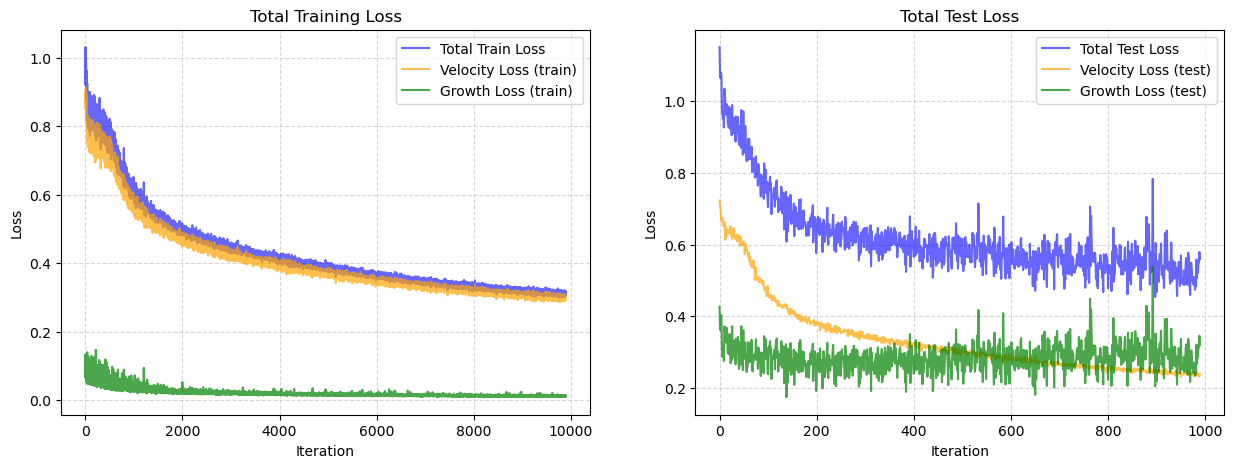

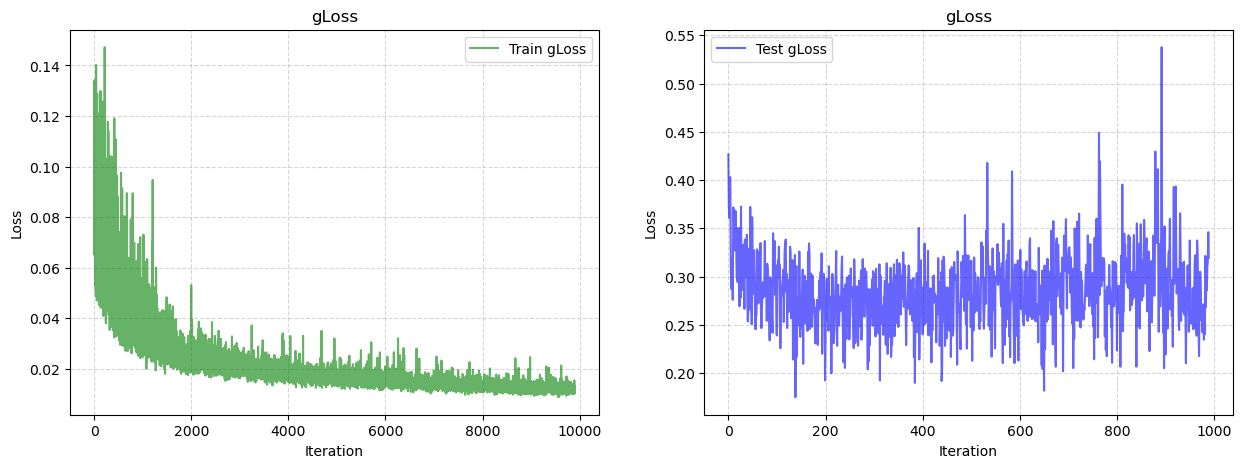

In [8]:
from src.evaluate import draw_loss
draw_loss(model_load_path,eval_interval = 10,cut = 100,save_path = results_save_path) # cut代表去掉前多少个epoch 避免前期loss过大影响观察

## inference & evalutaion

In [8]:
from src.evaluate.downstream import *
from src.evaluate.util import run_inference_and_reconstruct,evaluate_generated_results
from src.evaluate.evals_new import build_baseline_results

In [37]:
rulebook = adata_test.uns.get('global_rulebook')
if rulebook is None:
    raise ValueError("未找到 global_rulebook，请先确认数据经过了最新版 prepare_covariates 的处理！")

schema = rulebook["condition_tuple_schema"] 

# 我们直接从 adata_test 中，根据 schema 提取所有出现过的独立条件组合
# 然后直接转化为字典列表，这就是完美的 wishlist！
unique_conditions_df = adata_test.obs[schema].drop_duplicates()
wishlist = unique_conditions_df.to_dict(orient='records')

print(f"成功从测试集中提取了 {len(wishlist)} 个评估愿望 (Wishlist)！")
print(f"示例: {wishlist[0]}") 

# base_condition_key 通常是 schema 的第一个元素（如 'perturbation'）
base_condition_key = schema[0] 

# rulebook = adata_train.uns.get('global_rulebook')
# schema = rulebook["condition_tuple_schema"] 
# unique_conditions_df = adata_train.obs[schema].drop_duplicates()
# wishlist = unique_conditions_df.to_dict(orient='records')
# print(f"成功从测试集中提取了 {len(wishlist)} 个评估愿望 (Wishlist)！")
# print(f"示例: {wishlist[0]}") 
# base_condition_key = schema[0] 

成功从测试集中提取了 48 个评估愿望 (Wishlist)！
示例: {'cytokine': '4-1BBL', 'donor': 'Donor10'}


In [38]:
#wishlist = [{'cytokine': '4-1BBL', 'donor': 'Donor10'}] 
wishlist = [ k for k in wishlist if k['donor']=="Donor10"  ]

In [39]:
wishlist

[{'cytokine': '4-1BBL', 'donor': 'Donor10'},
 {'cytokine': 'ADSF', 'donor': 'Donor10'},
 {'cytokine': 'APRIL', 'donor': 'Donor10'},
 {'cytokine': 'BAFF', 'donor': 'Donor10'},
 {'cytokine': 'C5a', 'donor': 'Donor10'},
 {'cytokine': 'IFN-beta', 'donor': 'Donor10'},
 {'cytokine': 'IFN-epsilon', 'donor': 'Donor10'},
 {'cytokine': 'IL-13', 'donor': 'Donor10'},
 {'cytokine': 'IL-15', 'donor': 'Donor10'},
 {'cytokine': 'Noggin', 'donor': 'Donor10'},
 {'cytokine': 'OSM', 'donor': 'Donor10'},
 {'cytokine': 'OX40L', 'donor': 'Donor10'}]

In [49]:
from src.evaluate.util import run_inference_only
results_embedding, _, indices, reducer = run_inference_only(
    model=model,
    adata_control=adata_control,
    adata_test=adata_test,
    wishlist=wishlist,
    condition_keys=condition_keys,
    condition_rep_keys=condition_rep_keys,
    sample_rep=sample_rep,
    device=device,
    n_particles=200000,
    n_steps=100,
    source_celltype_key="cell_type",
    return_traj=True,
    save_times = (0.0, 0.25, 0.5, 0.75, 1.0),
    return_reducer=True,
    umap_n_neighbors = 30,
    umap_min_dist = 0.35,
    umap_random_state = 0,
    inference_modes=("all", "v_only", "g_only"),
)


Starting latent inference for 12 conditions...
Running inference for 12 conditions ...
Modes: ['all', 'v_only', 'g_only']


/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Latent inference completed.


In [50]:
ranked = sorted(
    [(k, v["all"]["m_pred"].mean()) for k, v in results_embedding.items()],
    key=lambda x: x[1]
)
print(ranked[:10])


[("('IFN-beta', 'Donor10')", np.float32(0.73004204)), ("('C5a', 'Donor10')", np.float32(0.84832)), ("('APRIL', 'Donor10')", np.float32(0.9038751)), ("('ADSF', 'Donor10')", np.float32(0.9454734)), ("('Noggin', 'Donor10')", np.float32(0.98431325)), ("('BAFF', 'Donor10')", np.float32(1.0770665)), ("('OX40L', 'Donor10')", np.float32(1.0795138)), ("('IFN-epsilon', 'Donor10')", np.float32(1.0944512)), ("('IL-15', 'Donor10')", np.float32(1.1229299)), ("('4-1BBL', 'Donor10')", np.float32(1.1523763))]


In [51]:
plt_save_path = "figures/PBMC"

In [ ]:
from src.evaluate.wfr_multitime_umap_helper import plot_multitime_umap_for_condition, plot_real_umap_for_condition

cond_name = "('IFN-beta', 'Donor10')"

adata_source_subset = adata_control[indices].copy()

fig, axes = plot_multitime_umap_for_condition(
    results=results_embedding,
    cond_name=cond_name,
    adata_source=adata_source_subset,
    sample_rep=sample_rep,
    save_times=(0.0, 0.25, 0.5, 0.75, 1.0),
    reducer=reducer,
    background="all_source",
    g_mode="all",
    point_size=10,
    show_ticks=False,
    title_prefix="Multi-time UMAP",
)
plt.savefig(f"{plt_save_path}/Multi-time UMAP_{cond_name}.pdf") 
plt.show()

xlim = axes[0, 0].get_xlim()
ylim = axes[0, 0].get_ylim()

fig_real, ax_real = plot_real_umap_for_condition(
    adata_test=adata_test,
    cond_name=cond_name,
    condition_key=condition_combined_keys,
    reducer=reducer,
    sample_rep=sample_rep,
    
    adata_background=adata_source_subset,
    background="all_source",
    time_key=None,
    time_value=1.0,

    adata_control=adata_source_subset,          
    control_celltype_key="cell_type",
    
    point_color="crimson",
    point_size=10.0,
    show_ticks=False,
    
    xlim=xlim,
    ylim=ylim,
)
plt.savefig(f"{plt_save_path}/True_treated_{cond_name}.pdf") 
plt.show()


In [ ]:
from src.evaluate.wfr_multitime_umap_helper import plot_multitime_umap_for_condition, plot_real_umap_for_condition

cond_name = "('IL-15', 'Donor10')"

adata_source_subset = adata_control[indices].copy()

fig, axes = plot_multitime_umap_for_condition(
    results=results_embedding,
    cond_name=cond_name,
    adata_source=adata_source_subset,
    sample_rep=sample_rep,
    save_times=(0.0, 0.25, 0.5, 0.75, 1.0),
    reducer=reducer,
    background="all_source",
    g_mode="all",
    point_size=10,
    show_ticks=False,
    title_prefix="Multi-time UMAP",
)
plt.savefig(f"{plt_save_path}/Multi-time UMAP_{cond_name}.pdf") 
plt.show()


xlim = axes[0, 0].get_xlim()
ylim = axes[0, 0].get_ylim()

fig_real, ax_real = plot_real_umap_for_condition(
    adata_test=adata_test,
    cond_name=cond_name,
    condition_key=condition_combined_keys,
    reducer=reducer,
    sample_rep=sample_rep,
    
    adata_background=adata_source_subset,
    background="all_source",
    time_key=None,
    time_value=1.0,

    adata_control=adata_source_subset,          
    control_celltype_key="cell_type",
    
    point_color="crimson",
    point_size=10.0,
    show_ticks=False,
    
    xlim=xlim,
    ylim=ylim,
)
plt.savefig(f"{plt_save_path}/True_treated_{cond_name}.pdf") 
plt.show()


## 画指标图

In [4]:
from src.evaluate.plot import plot_grouped_bar
import matplotlib.pyplot as plt

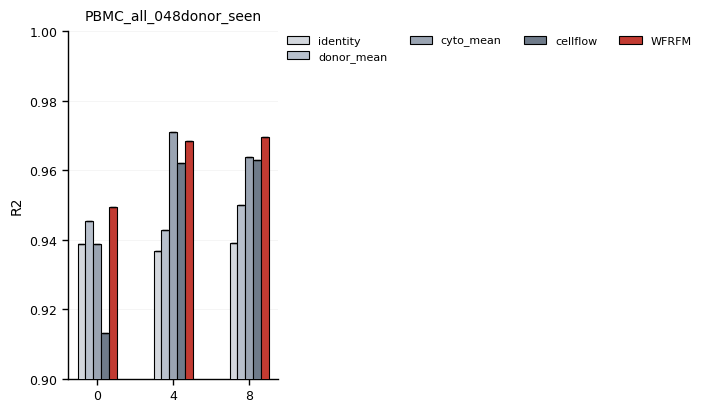

In [11]:
group_names = ["0", "4", "8"]
method_names = ["identity", "donor_mean", "cyto_mean","cellflow","WFRFM"]

data_dict = {
    "WFRFM":  [0.949411063026643,0.9682494068632020,0.9695699067691230],
    "identity": [0.9386843627595460,0.936854925431354,0.9391511381310260],
    "donor_mean": [0.9453620211544230,0.9428204904542800,0.950032554544835],
    "cyto_mean":  [0.9386843627595460,0.9710328326437350,0.9637383366773580],
    "cellflow": [0.913,0.962,0.963],
}

err_dict = {
     "WFRFM":  [0,0,0],
    "identity": [0,0,0],
    "donor_mean": [0,0,0],
    "cyto_mean":  [0,0,0],
    "cellflow": [0,0,0],
}

#colors = ["#C9CDD4", "#AEB6C2", "#8F99A8", "#6E7885", "#D94841"]

colors = ["#D3D7DD", "#B8C0CC", "#9AA4B2", "#6F7B8A", "#C23B32"]


fig, ax = plot_grouped_bar(
    data_dict=data_dict,
    group_names=group_names,
    method_names=method_names,
    y_label="R2",
    title="PBMC_all_048donor_seen",
    colors=colors,
    figsize=(7.2, 4.2),
    bar_width=0.18,
    group_gap=0.85,
    ylim=(0.9, 1.0),
    show_values=False,
    err_dict=err_dict,
    save_path="figures/PBMC/r2_048.pdf",
)

plt.show()


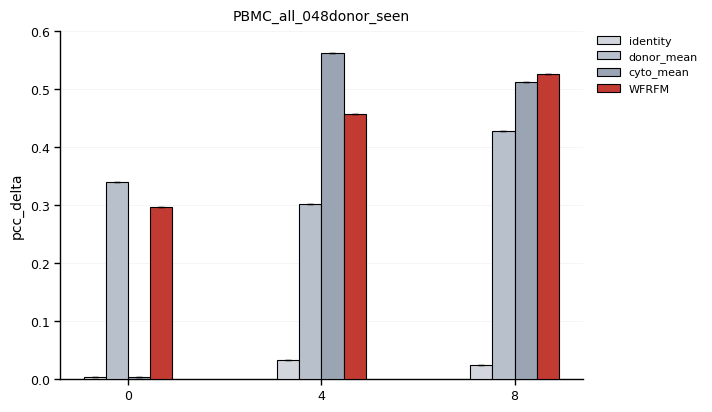

In [12]:
group_names = ["0", "4", "8"]
method_names = ["identity", "donor_mean", "cyto_mean","WFRFM"]

data_dict = {
    "WFRFM":  [0.296417651656319, 0.4563915156376480, 0.5263996162633090],
    "identity": [0.0027572391661459900, 0.031511109549986100, 0.022693043199383500],
    "donor_mean": [0.33906831654487500, 0.3014246471562110, 0.4266824208296150],
    "cyto_mean":  [0.0027572391661459900, 0.5613993533195450, 0.5118737951059470],
}

err_dict = {
     "WFRFM":  [0,0,0],
    "identity": [0,0,0],
    "donor_mean": [0,0,0],
    "cyto_mean":  [0,0,0],
}

colors = ["#D3D7DD", "#B8C0CC", "#9AA4B2", "#C23B32"]

fig, ax = plot_grouped_bar(
    data_dict=data_dict,
    group_names=group_names,
    method_names=method_names,
    y_label="pcc_delta",
    title="PBMC_all_048donor_seen",
    colors=colors,
    figsize=(7.2, 4.2),
    bar_width=0.18,
    group_gap=0.85,
    ylim=(0, 0.6),
    show_values=False,
    err_dict=err_dict,
    save_path="figures/PBMC/pcc_delta_048.pdf",
)

plt.show()


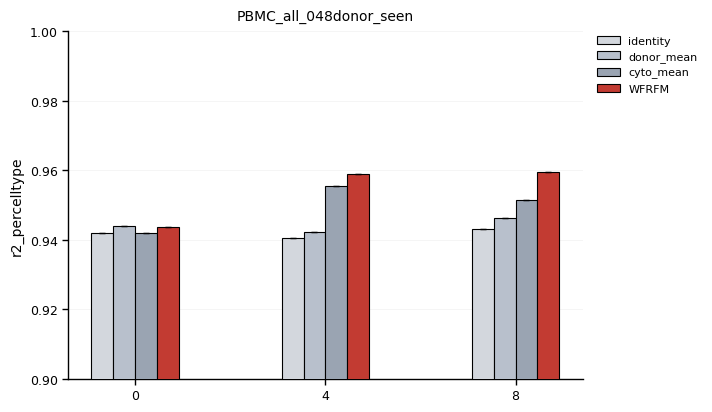

In [13]:
group_names = ["0", "4", "8"]
method_names = ["identity", "donor_mean", "cyto_mean","WFRFM"]

data_dict = {
    "WFRFM":  [0.9436206301147720, 0.9587703024009150, 0.9594893083430130],
    "identity": [0.9418804693154480, 0.9403810160438400, 0.9429669773428250],
    "donor_mean": [0.9438711493156230, 0.9422745314590090, 0.9462805258630900],
    "cyto_mean":  [0.9418804693154480, 0.9555237291706110, 0.9513417853413490],
}
err_dict = {
     "WFRFM":  [0,0,0],
    "identity": [0,0,0],
    "donor_mean": [0,0,0],
    "cyto_mean":  [0,0,0],
}

colors = ["#D3D7DD", "#B8C0CC", "#9AA4B2", "#C23B32"]



fig, ax = plot_grouped_bar(
    data_dict=data_dict,
    group_names=group_names,
    method_names=method_names,
    y_label="r2_percelltype",
    title="PBMC_all_048donor_seen",
    colors=colors,
    figsize=(7.2, 4.2),
    bar_width=0.18,
    group_gap=0.85,
    ylim=(0.9, 1.0),
    show_values=False,
    err_dict=err_dict,
    save_path="figures/PBMC/r2_percelltype_048.pdf",
)

plt.show()


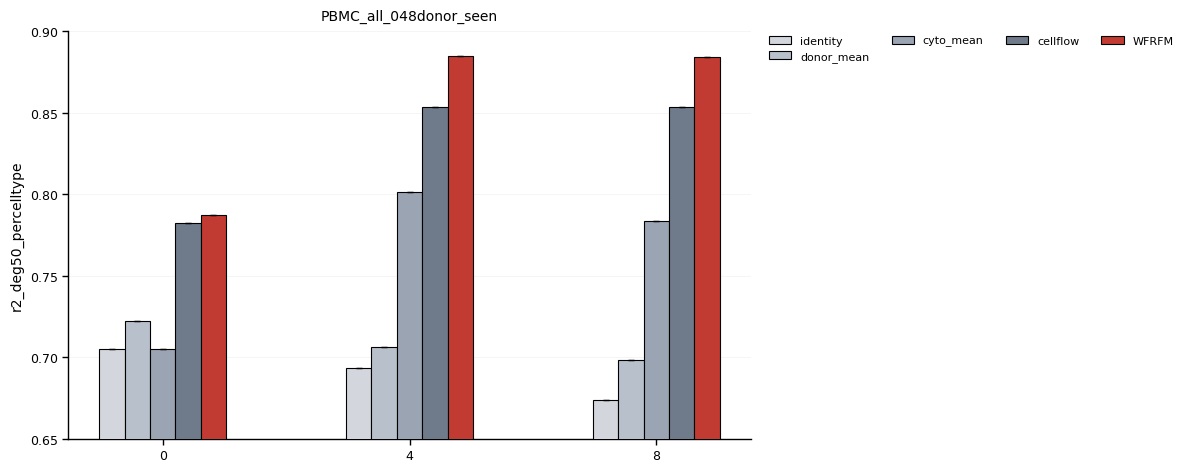

In [20]:
group_names = ["0", "4", "8"]#,"0", "4", "8","0", "4", "8","0", "4", "8"]
method_names = ["identity", "donor_mean", "cyto_mean","cellflow","WFRFM"]

data_dict = {
    "WFRFM":  [0.7873, 0.8845, 0.8844],#,0.7873, 0.8845, 0.8844,0.7873, 0.8845, 0.8844,0.7873, 0.8845, 0.8844],
    "identity": [0.7050, 0.6935, 0.6739],#,0.7050, 0.6935, 0.6739,0.7050, 0.6935, 0.6739,0.7050, 0.6935, 0.6739,],
    "donor_mean": [0.7219, 0.7060, 0.6985],#,0.7219, 0.7060, 0.6985,0.7219, 0.7060, 0.6985,0.7219, 0.7060, 0.6985],
    "cyto_mean":  [0.7050, 0.8012, 0.7832],#,0.7050, 0.8012, 0.7832,0.7050, 0.8012, 0.7832,0.7050, 0.8012, 0.7832],
    "cellflow": [0.7821, 0.8532, 0.8536],#,0.7821, 0.8532, 0.8536,0.7821, 0.8532, 0.8536,0.7821, 0.8532, 0.8536],
}
err_dict = {
     "WFRFM":  [0,0,0],#,0,0,0,0,0,0,0,0,0],
    "identity": [0,0,0],#,0,0,0,0,0,0,0,0,0],
    "donor_mean": [0,0,0],#,0,0,0,0,0,0,0,0,0],
    "cyto_mean":  [0,0,0],#,0,0,0,0,0,0,0,0,0],
    "cellflow": [0,0,0],#,0,0,0,0,0,0,0,0,0],
}

colors = ["#D3D7DD", "#B8C0CC", "#9AA4B2", "#6F7B8A", "#C23B32"]



fig, ax = plot_grouped_bar(
    data_dict=data_dict,
    group_names=group_names,
    method_names=method_names,
    y_label="r2_deg50_percelltype",
    title="PBMC_all_048donor_seen",
    colors=colors,
    figsize=(12, 4.8),
    bar_width=0.18,
    group_gap=0.85,
    ylim=(0.65, 0.9),
    show_values=False,
    err_dict=err_dict,
    save_path="figures/PBMC/r2_deg50_percelltype_048.pdf",
)

plt.show()


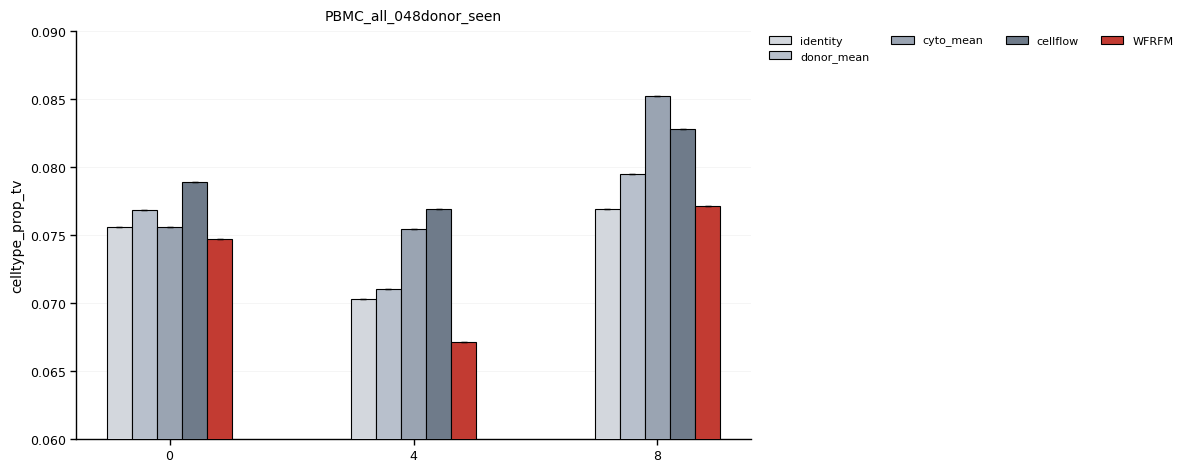

In [23]:
group_names = ["0", "4", "8"]#,"0", "4", "8","0", "4", "8","0", "4", "8"]
method_names = ["identity", "donor_mean", "cyto_mean","cellflow","WFRFM"]

data_dict = {
    "WFRFM":  [0.0747, 0.0671, 0.0771],#,0.0747, 0.0671, 0.0771,0.0747, 0.0671, 0.0771,0.0747, 0.0671, 0.0771],
    "identity": [0.0756, 0.0703, 0.0769],#,0.0756, 0.0703, 0.0769,0.0756, 0.0703, 0.0769,0.0756, 0.0703, 0.0769],
    "donor_mean": [0.0768, 0.0710, 0.0795],#,0.0768, 0.0710, 0.0795,0.0768, 0.0710, 0.0795,0.0768, 0.0710, 0.0795],
    "cyto_mean":  [0.0756, 0.0754, 0.0852],#,0.0756, 0.0754, 0.0852,0.0756, 0.0754, 0.0852,0.0756, 0.0754, 0.0852],
    "cellflow": [0.0789, 0.0769, 0.0828],#,0.0789, 0.0769, 0.0828,0.0789, 0.0769, 0.0828,0.0789, 0.0769, 0.0828],
}
err_dict = {
     "WFRFM":  [0,0,0],#,0,0,0,0,0,0,0,0,0],
    "identity": [0,0,0],#,0,0,0,0,0,0,0,0,0],
    "donor_mean": [0,0,0],#,0,0,0,0,0,0,0,0,0],
    "cyto_mean":  [0,0,0],#,0,0,0,0,0,0,0,0,0],
    "cellflow":  [0,0,0],#,0,0,0,0,0,0,0,0,0],
}

colors = ["#D3D7DD", "#B8C0CC", "#9AA4B2", "#6F7B8A", "#C23B32"]




fig, ax = plot_grouped_bar(
    data_dict=data_dict,
    group_names=group_names,
    method_names=method_names,
    y_label="celltype_prop_tv",
    title="PBMC_all_048donor_seen",
    colors=colors,
    figsize=(12, 4.8),
    bar_width=0.18,
    group_gap=0.85,
    ylim=(0.06, 0.09),
    show_values=False,
    err_dict=err_dict,
    save_path="figures/PBMC/celltype_prop_tv.pdf",
)

plt.show()


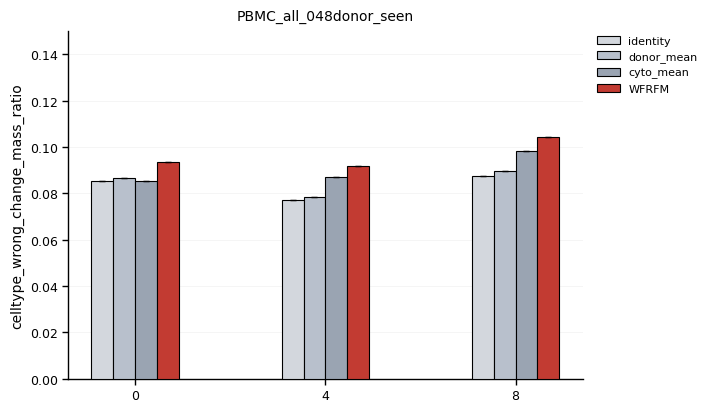

In [16]:
group_names = ["0", "4", "8"]
method_names = ["identity", "donor_mean", "cyto_mean","WFRFM"]

data_dict = {
    "WFRFM":  [0.09364323445618310, 0.09172190340267310, 0.10443035822350600],
    "identity": [0.0852645595411092, 0.07730783712414260, 0.08758831527349680],
    "donor_mean": [0.08669961050212820, 0.07825023229571290, 0.08953674962665120],
    "cyto_mean":  [0.0852645595411092, 0.08681137022269090, 0.09816042785837000],
}
err_dict = {
     "WFRFM":  [0,0,0],
    "identity": [0,0,0],
    "donor_mean": [0,0,0],
    "cyto_mean":  [0,0,0],
}

colors = ["#D3D7DD", "#B8C0CC", "#9AA4B2", "#C23B32"]



fig, ax = plot_grouped_bar(
    data_dict=data_dict,
    group_names=group_names,
    method_names=method_names,
    y_label="celltype_wrong_change_mass_ratio",
    title="PBMC_all_048donor_seen",
    colors=colors,
    figsize=(7.2, 4.2),
    bar_width=0.18,
    group_gap=0.85,
    ylim=(0, 0.15),
    show_values=False,
    err_dict=err_dict,
    save_path="figures/PBMC/celltype_wrong_change_mass_ratio.pdf",
)

plt.show()


## mass plot

In [9]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _get_matched_control(adata_control, pert_tuple_str, rulebook, use_groupwise_control=True):
    """
    根据 rulebook 动态解析 tuple 字符串，从 adata_control 中筛选精准的 Control 子集。
    若匹配失败则回退到全局 Control。
    """
    if not use_groupwise_control or not rulebook:
        return adata_control

    control_groups = rulebook.get("stratification", {}).get("control_groups", [])
    if len(control_groups) == 0:
        return adata_control

    control_groups = list(control_groups)
    schema = list(rulebook.get("condition_tuple_schema", []))

    try:
        actual_tuple = ast.literal_eval(pert_tuple_str)
        mask = np.ones(adata_control.n_obs, dtype=bool)

        for i, col in enumerate(schema):
            if col in control_groups:
                mask &= (adata_control.obs[col].astype(str) == str(actual_tuple[i]))

        curr_ctrl_sub = adata_control[mask]

        if curr_ctrl_sub.n_obs > 0:
            return curr_ctrl_sub
        else:
            print(f"⚠️ 警告: 未找到 {pert_tuple_str} 对应的 Groupwise Control，已回退到全局 Control。")
            return adata_control
    except Exception as e:
        print(f"⚠️ 警告: 解析 Control Tuple {pert_tuple_str} 失败 ({e})，已回退到全局 Control。")
        return adata_control


In [10]:
def compute_mass_mse_table(
    adata_test,
    adata_control,
    results_embedding,
    pert_key="cond_name",   # 你这里说 adata_test 里是 cond_name
    rulebook=None,
    use_groupwise_control=True,
    mass_deduct_keys=None,
    baseline_mode="one",    # "one" 表示 (1 - true_change)^2；"count_ratio" 表示更严格的不考虑 mass baseline
):
    """
    返回每个 cond 的:
      - true_change
      - baseline mse
      - predicted mse
      - pred_m / pred_change

    baseline_mode:
      - "one":        mse_baseline = (1 - true_change)^2
      - "count_ratio": mse_baseline = (count_ratio - true_change)^2
    """
    rows = []

    m_source_val = adata_control.uns.get("normalized_m", 1.0)
    m_target_val = adata_test.uns.get("normalized_m", 1.0)

    cond_list = adata_test.obs[pert_key].astype(str).unique().tolist()
    print(f"Start evaluating {len(cond_list)} conditions")

    for cond in cond_list:
        adata_true_pert = adata_test[adata_test.obs[pert_key].astype(str) == str(cond)]
        if adata_true_pert.n_obs == 0:
            continue

        curr_ctrl = _get_matched_control(
            adata_control=adata_control,
            pert_tuple_str=cond,
            rulebook=rulebook,
            use_groupwise_control=use_groupwise_control,
        )
        if curr_ctrl.n_obs == 0:
            continue

        n_test = adata_true_pert.n_obs
        n_control = curr_ctrl.n_obs

        if n_control == 0:
            continue

        count_ratio = n_test / n_control

        # ===== true_change: 你原始逻辑 =====
        if (
            mass_deduct_keys is not None
            and mass_deduct_keys in curr_ctrl.obs.columns
            and mass_deduct_keys in adata_true_pert.obs.columns
        ):
            n_unique_source = len(curr_ctrl.obs[mass_deduct_keys].unique())
            n_unique_target = len(adata_true_pert.obs[mass_deduct_keys].unique())
            adj_m_target = m_target_val * max(1, n_unique_source) / max(1, n_unique_target)
        else:
            adj_m_target = m_target_val

        true_change = (n_test * adj_m_target) / (n_control * m_source_val)

        # ===== baseline mse =====
        if baseline_mode == "one":
            baseline_pred = 1.0
        elif baseline_mode == "count_ratio":
            baseline_pred = count_ratio
        else:
            raise ValueError("baseline_mode must be 'one' or 'count_ratio'")

        mse_baseline = (baseline_pred - true_change) ** 2

        # ===== predicted mass from results_embedding =====
        if cond in results_embedding and "m_pred" in results_embedding[cond]:
            pred_m = np.asarray(results_embedding[cond]["m_pred"]).reshape(-1)
            pred_m_mean = float(np.nanmean(pred_m))
        else:
            pred_m_mean = np.nan

        mse_pred = (pred_m_mean - true_change) ** 2 if pd.notnull(pred_m_mean) else np.nan

        rows.append({
            "cond": cond,
            "n_test": n_test,
            "n_control": n_control,
            "count_ratio": count_ratio,
            "true_change": true_change,
            "baseline_pred": baseline_pred,
            "mse_baseline": mse_baseline,
            "pred_m_mean": pred_m_mean,
            "mse_pred": mse_pred,
        })

    return pd.DataFrame(rows)


In [11]:
if True:
    with open(f"{results_save_path}/inference_results.pkl", "rb") as f:
        inference_results = pickle.load(f)
        print(f"load inference_results")
    results_embedding = inference_results["results_embedding"]
    results_genes = inference_results["results_genes"]
    sampled_indices = inference_results["sampled_indices"]

load inference_results


In [12]:
df_eval = compute_mass_mse_table(
    adata_test=adata_test,
    adata_control=adata_control,
    results_embedding=results_embedding,
    pert_key=condition_combined_keys,
    rulebook=adata_control.uns["global_rulebook"],
    use_groupwise_control=True,
    mass_deduct_keys=mass_deduct_keys,
    baseline_mode="one",   # 对应 (1 - true_change)^2
)

df_eval.head()


Start evaluating 124 conditions


,cond,n_test,n_control,count_ratio,true_change,baseline_pred,mse_baseline,pred_m_mean,mse_pred
0,"('TAK-901', 'MCF7', 10000.0, 24.0)",125,7786,0.016054,0.256871,1.0,0.552240,0.688371,0.186192
1,"('Tanespimycin (17-AAG)', 'MCF7', 100.0, 24.0)",288,7786,0.036989,0.591831,1.0,0.166602,0.766199,0.030404
2,"('Dacinostat (LAQ824)', 'K562', 1000.0, 24.0)",116,3935,0.029479,0.471665,1.0,0.279138,0.536087,0.004150
3,"('Hesperadin', 'A549', 10.0, 72.0)",235,2084,0.112764,0.451056,1.0,0.301340,0.829808,0.143453
4,"('Quisinostat (JNJ-26481585) 2HCl', 'A549', 10...",185,3773,0.049033,0.784522,1.0,0.046431,0.788601,0.000017


In [15]:
import ast
import re
import warnings
from textwrap import wrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory


def _adjust_positions_axes_nm_v11(
    positions,
    min_dx=0.18,
    min_dy=0.12,
    x_bounds=(0.06, 0.94),
    y_bounds=(0.08, 0.92),
    n_iter=40,
):
    """
    Greedy repel in axes-fraction coordinates.
    Used for label/summary text placement.
    """
    pts = np.array(positions, dtype=float)

    if len(pts) <= 1:
        return [tuple(p) for p in pts]

    for _ in range(n_iter):
        moved = False

        for i in range(len(pts)):
            for j in range(i + 1, len(pts)):
                dx = pts[j, 0] - pts[i, 0]
                dy = pts[j, 1] - pts[i, 1]

                if abs(dx) < min_dx and abs(dy) < min_dy:
                    overlap_x = min_dx - abs(dx)
                    overlap_y = min_dy - abs(dy)

                    sx = 0.22 * overlap_x + 0.004
                    sy = 0.50 * overlap_y + 0.01

                    if pts[i, 1] <= pts[j, 1]:
                        pts[i, 1] -= sy
                        pts[j, 1] += sy
                    else:
                        pts[i, 1] += sy
                        pts[j, 1] -= sy

                    if pts[i, 0] <= pts[j, 0]:
                        pts[i, 0] -= sx
                        pts[j, 0] += sx
                    else:
                        pts[i, 0] += sx
                        pts[j, 0] -= sx

                    moved = True

        pts[:, 0] = np.clip(pts[:, 0], x_bounds[0], x_bounds[1])
        pts[:, 1] = np.clip(pts[:, 1], y_bounds[0], y_bounds[1])

        if not moved:
            break

    return [tuple(p) for p in pts]


def plot_mass_shift_repair_panel_v11_nm(
    df,
    cond_col="cond",
    true_col="true_change",
    pred_col="pred_m_mean",
    mse_baseline_col="mse_baseline",
    mse_pred_col="mse_pred",
    perturbation_col="perturbation",
    cell_line_col="cell_line",
    dose_col="dose_value",
    time_col="time",
    shift_threshold=1.25,
    use_log_error=True,
    right_panel="delta_group",   # "delta_group" or "shift_vs_delta"
    figsize=(7.9, 3.45),
    dpi=300,
    savepath=None,
    seed=0,
    highlight_specs=None,
    highlight_conds=None,
    wrap_width=28,
    max_label_lines=2,
    main_ylim=(0, 1.35),
    right_ylim=None,
    label_positions_axes=None,
    sort_highlight_by_x=True,
    panel_label="b",
    panel_label_pos=(-0.13, 1.04),
    verbose_match=False,
    model_label="Predicted",
    baseline_label="No change",
    abundance_label="Cell abundance (fold change)",
    n_boot=3000,
    show_p_values=True,
    show_median_delta=True,
    group_label_mode="state",   # "state" or "band"
    annotation_repel=True,

    # Main-panel visual switches
    show_stems=True,
    stem_only_shifting=True,
    show_cell_depletion_label=True,

    # Left highlight annotation
    annotation_fontsize=6.4,
    annotation_box_pad=0.16,
    annotation_min_dx=0.22,
    annotation_min_dy=0.15,
    annotation_box_alpha=0.90,
    annotation_style="clean",   # "clean" or "boxed"

    # No-change band label
    band_label_x_axes=0.31,
    band_label_y_data=None,
    band_label_fontsize=6.8,
    band_label_pad=0.16,
    band_label_style="clean",   # "clean" or "boxed"

    # Right y label
    right_ylabel=None,

    # Right summary text
    summary_box_positions=None,
    summary_box_fontsize=6.0,
    summary_box_pad=0.20,
    summary_box_min_dx=0.38,
    summary_box_min_dy=0.10,
    summary_style="text",       # "text" or "box"

    # Right panel note
    show_right_panel_note=False,
    right_panel_note="Higher is better",
):
    """
    Nature Methods-style v11 panel.

    Main panel:
        Ranked observed vs predicted abundance fold change.

    Right panel:
        Error reduction over no-change baseline.

        delta_error = baseline_error - model_error

        Positive values indicate that the model improves over the
        no-change baseline.

    Returns
    -------
    fig, ax_main, ax_right, plot_df, stats_df
    """

    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------------
    # 1. Publication-style rcParams and palette
    # ------------------------------------------------------------------
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7.5,
        "axes.labelsize": 8.8,
        "axes.titlesize": 8.8,
        "xtick.labelsize": 7.3,
        "ytick.labelsize": 7.3,
        "legend.fontsize": 7.3,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    })

    # Muted Nature-style palette
    c_obs = "#111111"
    c_pred = "#C5962C"
    c_base = "#7A7A7A"
    c_stem = "#D8D8D8"

    c_band = "#F4F7FA"
    c_band_edge = "#AAB5BF"
    c_band_text = "#5C6975"

    c_text = "#5B5B5B"
    c_grid = "#EEEEEE"
    c_annot_edge = "#D6D6D6"

    c_stable = "#B9BEC5"
    c_shift = c_pred

    # ------------------------------------------------------------------
    # 2. Validate and prepare dataframe
    # ------------------------------------------------------------------
    required_cols = [cond_col, true_col, pred_col]
    if not use_log_error:
        required_cols += [mse_baseline_col, mse_pred_col]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    optional_cols = []
    for c in [perturbation_col, cell_line_col, dose_col, time_col]:
        if c in df.columns:
            optional_cols.append(c)

    if highlight_specs is not None:
        for spec in highlight_specs:
            for k in spec.keys():
                if k in df.columns and k not in optional_cols:
                    optional_cols.append(k)

    use_cols = list(dict.fromkeys(required_cols + optional_cols))
    plot_df = df[use_cols].copy()

    numeric_cols = [true_col, pred_col]
    if not use_log_error:
        numeric_cols += [mse_baseline_col, mse_pred_col]

    for c in numeric_cols:
        plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=[true_col, pred_col])

    eps = 1e-8
    plot_df = plot_df[(plot_df[true_col] > 0) & (plot_df[pred_col] > 0)].copy()

    if len(plot_df) == 0:
        raise ValueError("No valid rows remain after filtering positive fold-change values.")

    # ------------------------------------------------------------------
    # 3. Parse cond if metadata columns are absent
    # ------------------------------------------------------------------
    def _normalize_text(x):
        if x is None:
            return ""
        try:
            if pd.isna(x):
                return ""
        except Exception:
            pass

        x = str(x)
        x = x.replace("µ", "u").replace("μ", "u")
        x = re.sub(r"\s+", " ", x)
        return x.strip().lower()

    def _parse_cond_to_parts(cond):
        if isinstance(cond, dict):
            return (
                cond.get("perturbation", np.nan),
                cond.get("cell_line", np.nan),
                cond.get("dose_value", np.nan),
                cond.get("time", np.nan),
            )

        if isinstance(cond, (tuple, list)) and len(cond) >= 4:
            return cond[0], cond[1], cond[2], cond[3]

        s = str(cond)

        try:
            val = ast.literal_eval(s)

            if isinstance(val, dict):
                return (
                    val.get("perturbation", np.nan),
                    val.get("cell_line", np.nan),
                    val.get("dose_value", np.nan),
                    val.get("time", np.nan),
                )

            if isinstance(val, (tuple, list)) and len(val) >= 4:
                return val[0], val[1], val[2], val[3]

        except Exception:
            pass

        return np.nan, np.nan, np.nan, np.nan

    parsed = plot_df[cond_col].apply(_parse_cond_to_parts)

    if perturbation_col not in plot_df.columns:
        plot_df["_perturbation_from_cond"] = parsed.apply(lambda z: z[0])
        perturbation_match_col = "_perturbation_from_cond"
    else:
        perturbation_match_col = perturbation_col

    if cell_line_col not in plot_df.columns:
        plot_df["_cell_line_from_cond"] = parsed.apply(lambda z: z[1])
        cell_line_match_col = "_cell_line_from_cond"
    else:
        cell_line_match_col = cell_line_col

    if dose_col not in plot_df.columns:
        plot_df["_dose_value_from_cond"] = pd.to_numeric(
            parsed.apply(lambda z: z[2]), errors="coerce"
        )
        dose_match_col = "_dose_value_from_cond"
    else:
        dose_match_col = dose_col
        plot_df[dose_match_col] = pd.to_numeric(plot_df[dose_match_col], errors="coerce")

    if time_col not in plot_df.columns:
        plot_df["_time_from_cond"] = pd.to_numeric(
            parsed.apply(lambda z: z[3]), errors="coerce"
        )
        time_match_col = "_time_from_cond"
    else:
        time_match_col = time_col
        plot_df[time_match_col] = pd.to_numeric(plot_df[time_match_col], errors="coerce")

    # ------------------------------------------------------------------
    # 4. Core derived quantities
    # ------------------------------------------------------------------
    plot_df["true_fc"] = plot_df[true_col].values
    plot_df["pred_fc"] = plot_df[pred_col].values

    plot_df["log2_true"] = np.log2(np.clip(plot_df["true_fc"].values, eps, None))
    plot_df["log2_pred"] = np.log2(np.clip(plot_df["pred_fc"].values, eps, None))

    band_lo = 1.0 / shift_threshold
    band_hi = shift_threshold
    shift_thr_log2 = np.log2(shift_threshold)

    plot_df["abs_mass_shift_log2"] = np.abs(plot_df["log2_true"])
    plot_df["mass_group"] = np.where(
        plot_df["true_fc"].between(band_lo, band_hi, inclusive="both"),
        "Stable",
        "Shifting",
    )

    if use_log_error:
        plot_df["baseline_error"] = np.abs(plot_df["log2_true"])
        plot_df["model_error"] = np.abs(plot_df["log2_pred"] - plot_df["log2_true"])
        error_unit = "log2"
    else:
        plot_df["baseline_error"] = pd.to_numeric(plot_df[mse_baseline_col], errors="coerce")
        plot_df["model_error"] = pd.to_numeric(plot_df[mse_pred_col], errors="coerce")
        error_unit = "MSE"

    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=["baseline_error", "model_error"]).copy()

    plot_df["delta_error"] = plot_df["baseline_error"] - plot_df["model_error"]
    plot_df["improved"] = plot_df["delta_error"] > 0

    plot_df = plot_df.sort_values("true_fc").reset_index(drop=True)

    x = np.arange(len(plot_df))
    y_true = plot_df["true_fc"].values
    y_pred = plot_df["pred_fc"].values
    is_shift = plot_df["mass_group"].eq("Shifting").values

    # ------------------------------------------------------------------
    # 5. Helper functions
    # ------------------------------------------------------------------
    def _wrap_label(s, width=28, max_lines=2):
        s = str(s)
        lines = wrap(s, width=width)

        if len(lines) > max_lines:
            lines = lines[:max_lines]
            if len(lines[-1]) > 3:
                lines[-1] = lines[-1][:-3] + "..."
            else:
                lines[-1] = lines[-1] + "..."

        return "\n".join(lines)

    def _format_dose(v):
        if pd.isna(v):
            return ""

        v = float(v)

        if v >= 1000:
            return f"{v / 1000:g} µM"

        return f"{v:g} nM"

    def _format_label(row):
        pert = row.get(perturbation_match_col, np.nan)
        cell = row.get(cell_line_match_col, np.nan)
        dose = row.get(dose_match_col, np.nan)
        time = row.get(time_match_col, np.nan)

        if not pd.isna(pert) and not pd.isna(cell):
            dose_txt = _format_dose(dose)
            time_txt = f"{float(time):g} h" if not pd.isna(time) else ""
            suffix = " • ".join([z for z in [str(cell), dose_txt, time_txt] if z])
            return f"{pert}\n{suffix}"

        return _wrap_label(row[cond_col], width=wrap_width, max_lines=max_label_lines)

    def _num_token(v):
        v = float(v)
        if abs(v - round(v)) < 1e-8:
            return str(int(round(v)))
        return str(v)

    def _match_one_spec(spec):
        mask = np.ones(len(plot_df), dtype=bool)

        if "perturbation" in spec:
            q = _normalize_text(spec["perturbation"])
            vals = plot_df[perturbation_match_col].map(_normalize_text)

            exact_mask = vals.eq(q)
            if exact_mask.any():
                mask &= exact_mask.values
            else:
                contains_mask = vals.apply(lambda v: (q in v) or (v in q) if v else False)
                mask &= contains_mask.values

        if "cell_line" in spec:
            q = _normalize_text(spec["cell_line"])
            vals = plot_df[cell_line_match_col].map(_normalize_text)
            mask &= vals.eq(q).values

        if "dose_value" in spec:
            q = float(spec["dose_value"])
            vals = pd.to_numeric(plot_df[dose_match_col], errors="coerce")
            mask &= np.isclose(vals, q, atol=1e-6, rtol=1e-6)

        if "time" in spec:
            q = float(spec["time"])
            vals = pd.to_numeric(plot_df[time_match_col], errors="coerce")
            mask &= np.isclose(vals, q, atol=1e-6, rtol=1e-6)

        matches = plot_df.index[mask].tolist()

        if len(matches) == 0:
            raw = plot_df[cond_col].astype(str).map(_normalize_text)
            raw_mask = np.ones(len(plot_df), dtype=bool)

            if "perturbation" in spec:
                q = _normalize_text(spec["perturbation"])
                raw_mask &= raw.str.contains(re.escape(q), regex=True, na=False).values

            if "cell_line" in spec:
                q = _normalize_text(spec["cell_line"])
                raw_mask &= raw.str.contains(re.escape(q), regex=True, na=False).values

            if "dose_value" in spec:
                q = _num_token(spec["dose_value"])
                raw_mask &= raw.str.contains(q, regex=False, na=False).values

            if "time" in spec:
                q = _num_token(spec["time"])
                raw_mask &= raw.str.contains(q, regex=False, na=False).values

            matches = plot_df.index[raw_mask].tolist()

        return matches

    def _find_highlight_indices():
        idxs = []

        if highlight_specs is not None:
            for spec in highlight_specs:
                matches = _match_one_spec(spec)

                if matches:
                    idxs.append(matches[0])
                    if verbose_match:
                        print("[highlight matched]", spec, "->", plot_df.loc[matches[0], cond_col])
                else:
                    warnings.warn(
                        f"Could not match highlight spec: {spec}. "
                        f"Try checking df rows containing the perturbation name."
                    )

        if highlight_conds is not None:
            conds_all = plot_df[cond_col].astype(str).tolist()

            for q in highlight_conds:
                q = str(q)

                if q in conds_all:
                    idxs.append(conds_all.index(q))
                else:
                    q_norm = _normalize_text(q)
                    matches = [
                        i for i, c in enumerate(conds_all)
                        if q_norm in _normalize_text(c)
                    ]

                    if matches:
                        idxs.append(matches[0])
                    else:
                        warnings.warn(f"Could not find highlight cond: {q}")

        if len(idxs) == 0:
            idx_left = int(np.argmin(y_true))
            idx_right = int(np.argmax(y_true))

            shifting_df = plot_df[plot_df["mass_group"] == "Shifting"].copy()
            if len(shifting_df) > 0:
                idx_rescue = int(shifting_df["delta_error"].idxmax())
            else:
                idx_rescue = idx_right

            idxs = [idx_left, idx_rescue, idx_right]

        idxs = list(dict.fromkeys(idxs))

        if sort_highlight_by_x:
            idxs = sorted(idxs, key=lambda i: x[i])

        return idxs

    def _bootstrap_ci(values, func=np.median, n_boot=3000, ci=95):
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if len(values) == 0:
            return np.nan, np.nan, np.nan

        center = func(values)

        if len(values) == 1 or n_boot <= 0:
            return center, np.nan, np.nan

        boot = []
        for _ in range(n_boot):
            sample = rng.choice(values, size=len(values), replace=True)
            boot.append(func(sample))

        alpha = (100 - ci) / 2
        lo, hi = np.percentile(boot, [alpha, 100 - alpha])

        return center, lo, hi

    def _safe_paired_pvalue(base_err, model_err):
        base_err = np.asarray(base_err, dtype=float)
        model_err = np.asarray(model_err, dtype=float)

        mask = np.isfinite(base_err) & np.isfinite(model_err)
        base_err = base_err[mask]
        model_err = model_err[mask]

        if len(base_err) < 2:
            return np.nan, "NA"

        diff = base_err - model_err
        diff = diff[np.isfinite(diff)]
        diff = diff[diff != 0]

        if len(diff) < 2:
            return np.nan, "NA"

        try:
            from scipy.stats import wilcoxon
            result = wilcoxon(
                base_err,
                model_err,
                alternative="two-sided",
                zero_method="wilcox",
            )
            return float(result.pvalue), "Wilcoxon"

        except Exception:
            n = len(diff)
            k = int(np.sum(diff > 0))
            k_tail = min(k, n - k)

            prob = 0.0
            for i in range(k_tail + 1):
                prob += np.math.comb(n, i) * (0.5 ** n)

            p = min(1.0, 2.0 * prob)
            return float(p), "Sign"

    def _format_p(p):
        if p is None or not np.isfinite(p):
            return "P=NA"
        if p < 1e-4:
            return "P<1e-4"
        if p < 1e-3:
            return f"P={p:.1e}"
        return f"P={p:.3f}"

    def _summarize_group(name, mask):
        sub = plot_df.loc[mask].copy()

        vals = sub["delta_error"].values
        base = sub["baseline_error"].values
        model = sub["model_error"].values

        med, ci_lo, ci_hi = _bootstrap_ci(vals, np.median, n_boot=n_boot)
        p, test_name = _safe_paired_pvalue(base, model)

        n = len(sub)
        n_improved = int(np.sum(sub["delta_error"] > 0))
        pct_improved = 100 * n_improved / n if n > 0 else np.nan

        return {
            "group": name,
            "n": n,
            "n_improved": n_improved,
            "pct_improved": pct_improved,
            "median_delta_error": med,
            "median_delta_error_ci_low": ci_lo,
            "median_delta_error_ci_high": ci_hi,
            "p_value": p,
            "test": test_name,
            "median_baseline_error": np.nanmedian(base) if len(base) else np.nan,
            "median_model_error": np.nanmedian(model) if len(model) else np.nan,
        }

    highlight_idx = _find_highlight_indices()

    stable_mask = plot_df["mass_group"].eq("Stable")
    shifting_mask = plot_df["mass_group"].eq("Shifting")

    stats_df = pd.DataFrame([
        _summarize_group("Stable", stable_mask),
        _summarize_group("Shifting", shifting_mask),
    ])

    # ------------------------------------------------------------------
    # 6. Figure layout
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize, dpi=dpi)

    gs = fig.add_gridspec(
        1,
        2,
        width_ratios=[5.8, 2.05],
        wspace=0.24,
    )

    ax = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[0, 1])

    fig.subplots_adjust(
        left=0.095,
        right=0.985,
        top=0.885,
        bottom=0.29,
        wspace=0.24,
    )

    # ------------------------------------------------------------------
    # 7. Main panel
    # ------------------------------------------------------------------
    ax.axhspan(
        band_lo,
        band_hi,
        color=c_band,
        alpha=1.0,
        zorder=0,
    )

    ax.axhline(
        1.0,
        color=c_base,
        lw=0.95,
        ls=(0, (3, 2)),
        zorder=1.2,
    )

    for yb in (band_lo, band_hi):
        ax.axhline(
            yb,
            color=c_band_edge,
            lw=0.85,
            ls=(0, (3, 2)),
            zorder=1.1,
        )

    if show_stems:
        if stem_only_shifting:
            stem_x = x[is_shift]
            stem_y = y_true[is_shift]
        else:
            stem_x = x
            stem_y = y_true

        ax.vlines(
            stem_x,
            1.0,
            stem_y,
            color=c_stem,
            lw=0.55,
            alpha=0.65,
            zorder=1,
        )

    ax.plot(
        x,
        y_true,
        color=c_obs,
        lw=0.95,
        alpha=0.95,
        zorder=2,
    )

    ax.scatter(
        x,
        y_true,
        s=13,
        color=c_obs,
        zorder=3,
    )

    ax.scatter(
        x,
        y_pred,
        s=17,
        color=c_pred,
        edgecolors="none",
        alpha=0.88,
        zorder=4,
    )

    if len(highlight_idx) > 0:
        ax.scatter(
            x[highlight_idx],
            y_true[highlight_idx],
            s=58,
            facecolors="none",
            edgecolors="#666666",
            linewidths=0.85,
            zorder=5,
        )

    ax.set_xlabel(f"Conditions ranked by observed fold change (n={len(plot_df)})")
    ax.set_ylabel(abundance_label)
    ax.set_xticks([])
    ax.margins(x=0.02)

    if main_ylim is not None:
        ax.set_ylim(main_ylim)
    else:
        lower = max(0.0, np.nanmin(np.r_[y_true, y_pred]) - 0.03)
        upper = max(
            band_hi + 0.05,
            np.nanpercentile(np.r_[y_true, y_pred], 92) + 0.05,
        )
        upper = min(upper, 1.40)
        ax.set_ylim(lower, upper)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        panel_label_pos[0],
        panel_label_pos[1],
        panel_label,
        transform=ax.transAxes,
        fontsize=12.5,
        fontweight="bold",
        ha="left",
        va="top",
        color="black",
    )

    # ------------------------------------------------------------------
    # 7.1 No-change band bracket and label
    # ------------------------------------------------------------------
    band_trans = blended_transform_factory(ax.transAxes, ax.transData)
    x_bracket = 0.018
    x_tick = 0.028

    ax.plot(
        [x_bracket, x_bracket],
        [band_lo, band_hi],
        transform=band_trans,
        color=c_band_edge,
        lw=0.9,
        clip_on=False,
        zorder=2,
    )

    ax.plot(
        [x_bracket, x_tick],
        [band_lo, band_lo],
        transform=band_trans,
        color=c_band_edge,
        lw=0.9,
        clip_on=False,
        zorder=2,
    )

    ax.plot(
        [x_bracket, x_tick],
        [band_hi, band_hi],
        transform=band_trans,
        color=c_band_edge,
        lw=0.9,
        clip_on=False,
        zorder=2,
    )

    if band_label_y_data is None:
        band_label_y_data = 0.5 * (band_lo + band_hi)

    if band_label_style == "boxed":
        band_bbox = dict(
            boxstyle=f"round,pad={band_label_pad}",
            fc="white",
            ec=c_band_edge,
            lw=0.5,
            alpha=0.94,
        )
    else:
        band_bbox = dict(
            boxstyle=f"square,pad={band_label_pad}",
            fc="white",
            ec="none",
            alpha=0.86,
        )

    band_text_artist = ax.text(
        band_label_x_axes,
        band_label_y_data,
        f"No-change band\n({band_lo:.2f}×–{band_hi:.2f}×)",
        transform=band_trans,
        ha="left",
        va="center",
        color=c_band_text,
        fontsize=band_label_fontsize,
        fontweight="semibold",
        bbox=band_bbox,
        zorder=3,
    )

    if band_label_style == "clean":
        band_text_artist.set_path_effects([
            pe.withStroke(linewidth=1.0, foreground="white"),
            pe.Normal(),
        ])

    if show_cell_depletion_label:
        ax.text(
            0.98,
            0.055,
            "Cell depletion",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            color=c_text,
            fontsize=7.5,
        )

    # ------------------------------------------------------------------
    # 7.2 Legend
    # ------------------------------------------------------------------
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=c_obs,
            markeredgecolor=c_obs,
            markersize=4.4,
            label="Observed",
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=c_pred,
            markeredgecolor=c_pred,
            markeredgewidth=0,
            markersize=4.8,
            label=model_label,
        ),
        Line2D(
            [0], [0],
            color=c_base,
            lw=0.95,
            ls=(0, (3, 2)),
            label=baseline_label,
        ),
    ]

    ax.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(0.0, 1.01),
        ncol=3,
        frameon=False,
        handlelength=1.25,
        columnspacing=0.75,
        handletextpad=0.35,
        borderaxespad=0.0,
    )

    # ------------------------------------------------------------------
    # 8. Main-panel annotations
    # ------------------------------------------------------------------
    if label_positions_axes is None:
        default_positions = [
            (0.15, 0.13),
            (0.47, 0.14),
            (0.93, 0.29),
            (0.26, 0.48),
            (0.58, 0.58),
        ]
        label_positions_axes = default_positions[:len(highlight_idx)]

    if annotation_repel and len(label_positions_axes) > 1:
        label_positions_axes = _adjust_positions_axes_nm_v11(
            label_positions_axes,
            min_dx=annotation_min_dx,
            min_dy=annotation_min_dy,
            x_bounds=(0.06, 0.95),
            y_bounds=(0.08, 0.88),
            n_iter=40,
        )

    for i, idx in enumerate(highlight_idx):
        if i >= len(label_positions_axes):
            break

        fx, fy = label_positions_axes[i]
        label = _format_label(plot_df.loc[idx])

        if fx < 0.30:
            ha = "left"
        elif fx > 0.70:
            ha = "right"
        else:
            ha = "center"

        if annotation_style == "boxed":
            ann_bbox = dict(
                boxstyle=f"round,pad={annotation_box_pad}",
                fc="white",
                ec=c_annot_edge,
                lw=0.60,
                alpha=0.96,
            )
            connectionstyle = "arc3,rad=0.04"
        else:
            ann_bbox = dict(
                boxstyle=f"square,pad={annotation_box_pad}",
                fc="white",
                ec="none",
                alpha=annotation_box_alpha,
            )
            connectionstyle = "angle3,angleA=0,angleB=90"

        ann = ax.annotate(
            label,
            xy=(x[idx], y_true[idx]),
            xycoords="data",
            xytext=(fx, fy),
            textcoords="axes fraction",
            ha=ha,
            va="center",
            fontsize=annotation_fontsize,
            color="#222222",
            bbox=ann_bbox,
            arrowprops=dict(
                arrowstyle="-",
                color="#9A9A9A",
                lw=0.75,
                shrinkA=2,
                shrinkB=2,
                connectionstyle=connectionstyle,
            ),
            zorder=6,
        )

        if annotation_style == "clean":
            ann.set_path_effects([
                pe.withStroke(linewidth=0.8, foreground="white"),
                pe.Normal(),
            ])

    # ------------------------------------------------------------------
    # 9. Right panel
    # ------------------------------------------------------------------
    if right_panel not in {"delta_group", "shift_vs_delta"}:
        raise ValueError("right_panel must be either 'delta_group' or 'shift_vs_delta'.")

    if right_ylabel is None:
        if error_unit == "log2":
            right_ylabel = (
                "Reduction in absolute prediction error\n"
                "vs no-change baseline"
            )
        else:
            right_ylabel = (
                "Reduction in prediction error\n"
                "vs no-change baseline"
            )

    if right_panel == "delta_group":
        _draw_delta_group_panel_v11_nm(
            ax_right=ax_right,
            plot_df=plot_df,
            stats_df=stats_df,
            stable_mask=stable_mask,
            shifting_mask=shifting_mask,
            c_stable=c_stable,
            c_shift=c_shift,
            c_grid=c_grid,
            rng=rng,
            error_unit=error_unit,
            right_ylim=right_ylim,
            show_p_values=show_p_values,
            show_median_delta=show_median_delta,
            format_p_func=_format_p,
            group_label_mode=group_label_mode,
            right_ylabel=right_ylabel,
            summary_box_positions=summary_box_positions,
            summary_box_fontsize=summary_box_fontsize,
            summary_box_pad=summary_box_pad,
            summary_box_min_dx=summary_box_min_dx,
            summary_box_min_dy=summary_box_min_dy,
            summary_style=summary_style,
            show_right_panel_note=show_right_panel_note,
            right_panel_note=right_panel_note,
        )

    else:
        _draw_shift_vs_delta_panel_v11_nm(
            ax_right=ax_right,
            plot_df=plot_df,
            shift_threshold=shift_threshold,
            shift_thr_log2=shift_thr_log2,
            c_stable=c_stable,
            c_shift=c_shift,
            c_grid=c_grid,
            error_unit=error_unit,
            right_ylim=right_ylim,
            group_label_mode=group_label_mode,
            right_ylabel=right_ylabel,
        )

    # ------------------------------------------------------------------
    # 10. Save
    # ------------------------------------------------------------------
    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

    return fig, ax, ax_right, plot_df, stats_df


def _draw_delta_group_panel_v11_nm(
    ax_right,
    plot_df,
    stats_df,
    stable_mask,
    shifting_mask,
    c_stable,
    c_shift,
    c_grid,
    rng,
    error_unit="log2",
    right_ylim=None,
    show_p_values=True,
    show_median_delta=True,
    format_p_func=None,
    group_label_mode="state",
    right_ylabel=None,
    summary_box_positions=None,
    summary_box_fontsize=6.0,
    summary_box_pad=0.20,
    summary_box_min_dx=0.38,
    summary_box_min_dy=0.10,
    summary_style="text",
    show_right_panel_note=False,
    right_panel_note="Higher is better",
):
    """
    Right panel: grouped error reduction plot.

    Positive delta_error means model improves over no-change.
    """

    def _fmt_signed(v):
        if v is None or not np.isfinite(v):
            return "NA"
        return f"{v:+.2f}"

    data = [
        plot_df.loc[stable_mask, "delta_error"].values,
        plot_df.loc[shifting_mask, "delta_error"].values,
    ]

    positions = [1.0, 2.0]
    colors = [c_stable, c_shift]

    if group_label_mode == "band":
        labels = [
            f"Within band\n(n={int(stable_mask.sum())})",
            f"Outside band\n(n={int(shifting_mask.sum())})",
        ]
    else:
        labels = [
            f"Stable\n(n={int(stable_mask.sum())})",
            f"Shifting\n(n={int(shifting_mask.sum())})",
        ]

    ax_right.axhline(
        0,
        color="#7A7A7A",
        lw=0.95,
        ls=(0, (3, 2)),
        zorder=1,
    )

    ax_right.set_axisbelow(True)
    ax_right.yaxis.grid(True, color=c_grid, linewidth=0.7)
    ax_right.xaxis.grid(False)

    # Light jitter points
    for arr, pos, col in zip(data, positions, colors):
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]

        if len(arr) == 0:
            continue

        jitter = rng.normal(0, 0.032, size=len(arr))

        ax_right.scatter(
            np.full(len(arr), pos) + jitter,
            arr,
            s=12,
            color=col,
            alpha=0.24,
            linewidths=0,
            zorder=2,
        )

    bp = ax_right.boxplot(
        data,
        positions=positions,
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="#111111", linewidth=1.1),
        whiskerprops=dict(color="#4A4A4A", linewidth=0.8),
        capprops=dict(color="#4A4A4A", linewidth=0.8),
        boxprops=dict(color="#4A4A4A", linewidth=0.8),
    )

    for patch, col in zip(bp["boxes"], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.90)

    finite_vals = (
        np.concatenate([
            np.asarray(arr, dtype=float)[np.isfinite(arr)]
            for arr in data
            if len(arr) > 0
        ])
        if any(len(arr) > 0 for arr in data)
        else np.array([0.0])
    )

    if right_ylim is not None:
        ax_right.set_ylim(right_ylim)
    else:
        y_min = np.nanmin(finite_vals)
        y_max = np.nanmax(finite_vals)

        y_min = min(y_min, 0)
        y_max = max(y_max, 0)

        y_range = y_max - y_min
        if y_range <= 0:
            y_range = 1.0

        ax_right.set_ylim(
            y_min - 0.18 * y_range,
            y_max + 0.36 * y_range,
        )

    ax_right.set_xlim(0.45, 2.55)
    ax_right.set_xticks(positions)
    ax_right.set_xticklabels(labels)
    ax_right.tick_params(axis="x", length=0, pad=4)

    ax_right.set_ylabel(right_ylabel)

    if show_right_panel_note:
        ax_right.text(
            0.03,
            0.90,
            right_panel_note,
            transform=ax_right.transAxes,
            ha="left",
            va="top",
            fontsize=6.7,
            color="#5A5A5A",
        )

    group_names = ["Stable", "Shifting"]

    if summary_box_positions is None:
        summary_box_positions = [(0.28, 0.96), (0.72, 0.96)]

    if len(summary_box_positions) > 1:
        summary_box_positions = _adjust_positions_axes_nm_v11(
            summary_box_positions,
            min_dx=summary_box_min_dx,
            min_dy=summary_box_min_dy,
            x_bounds=(0.10, 0.90),
            y_bounds=(0.84, 0.98),
            n_iter=40,
        )

    for (xfrac, yfrac), group_name in zip(summary_box_positions, group_names):
        row = stats_df.loc[stats_df["group"] == group_name].iloc[0]

        pct = row["pct_improved"]
        med = row["median_delta_error"]
        p = row["p_value"]

        lines = [f"{pct:.0f}% improved"]

        if show_median_delta:
            lines.append(f"Median Δ {_fmt_signed(med)}")

        if show_p_values and format_p_func is not None:
            lines.append(format_p_func(p))

        if summary_style == "box":
            txt = ax_right.text(
                xfrac,
                yfrac,
                "\n".join(lines),
                transform=ax_right.transAxes,
                ha="center",
                va="top",
                fontsize=summary_box_fontsize,
                color="#2A2A2A",
                bbox=dict(
                    boxstyle=f"round,pad={summary_box_pad}",
                    fc="white",
                    ec="#D8D8D8",
                    lw=0.45,
                    alpha=0.96,
                ),
                zorder=5,
            )
        else:
            txt = ax_right.text(
                xfrac,
                yfrac,
                "\n".join(lines),
                transform=ax_right.transAxes,
                ha="center",
                va="top",
                fontsize=summary_box_fontsize,
                color="#4A4A4A",
                zorder=5,
            )

            txt.set_path_effects([
                pe.withStroke(linewidth=1.2, foreground="white"),
                pe.Normal(),
            ])

    ax_right.spines["top"].set_visible(False)
    ax_right.spines["right"].set_visible(False)


def _draw_shift_vs_delta_panel_v11_nm(
    ax_right,
    plot_df,
    shift_threshold,
    shift_thr_log2,
    c_stable,
    c_shift,
    c_grid,
    error_unit="log2",
    right_ylim=None,
    group_label_mode="state",
    right_ylabel=None,
):
    """
    Alternative right panel:
    relationship between observed shift magnitude and model benefit.
    """

    is_shift = plot_df["mass_group"].eq("Shifting").values
    xval = plot_df["abs_mass_shift_log2"].values
    yval = plot_df["delta_error"].values

    stable_label = "Within band" if group_label_mode == "band" else "Stable"
    shift_label = "Outside band" if group_label_mode == "band" else "Shifting"

    ax_right.axhline(
        0,
        color="#7A7A7A",
        lw=0.95,
        ls=(0, (3, 2)),
        zorder=1,
    )

    ax_right.axvline(
        shift_thr_log2,
        color="#9A9A9A",
        lw=0.85,
        ls=(0, (3, 2)),
        zorder=1,
    )

    ax_right.scatter(
        xval[~is_shift],
        yval[~is_shift],
        s=13,
        color=c_stable,
        alpha=0.36,
        linewidths=0,
        label=stable_label,
        zorder=2,
    )

    ax_right.scatter(
        xval[is_shift],
        yval[is_shift],
        s=13,
        color=c_shift,
        alpha=0.50,
        linewidths=0,
        label=shift_label,
        zorder=3,
    )

    valid = np.isfinite(xval) & np.isfinite(yval)
    xv = xval[valid]
    yv = yval[valid]

    if len(xv) >= 12:
        quantiles = np.linspace(0, 1, 6)
        edges = np.unique(np.quantile(xv, quantiles))

        bx = []
        by = []

        for lo, hi in zip(edges[:-1], edges[1:]):
            if hi == edges[-1]:
                mask = (xv >= lo) & (xv <= hi)
            else:
                mask = (xv >= lo) & (xv < hi)

            if mask.sum() >= 2:
                bx.append(np.median(xv[mask]))
                by.append(np.median(yv[mask]))

        if len(bx) >= 2:
            ax_right.plot(
                bx,
                by,
                color="#111111",
                lw=1.05,
                marker="o",
                markersize=3.0,
                zorder=4,
                label="Binned median",
            )

    ax_right.set_axisbelow(True)
    ax_right.yaxis.grid(True, color=c_grid, linewidth=0.7)
    ax_right.xaxis.grid(False)

    if right_ylim is not None:
        ax_right.set_ylim(right_ylim)
    else:
        y_min = np.nanmin(yval)
        y_max = np.nanmax(yval)

        y_min = min(y_min, 0)
        y_max = max(y_max, 0)

        y_range = y_max - y_min
        if y_range <= 0:
            y_range = 1.0

        ax_right.set_ylim(
            y_min - 0.18 * y_range,
            y_max + 0.20 * y_range,
        )

    ax_right.set_xlabel("|Observed change| (log2)")
    ax_right.set_ylabel(right_ylabel)

    ax_right.text(
        0.97,
        0.03,
        f"Threshold = ±{shift_threshold:g}-fold",
        transform=ax_right.transAxes,
        ha="right",
        va="bottom",
        fontsize=6.8,
        color="#5A5A5A",
    )

    ax_right.legend(
        frameon=False,
        fontsize=6.6,
        loc="upper left",
        handlelength=1.0,
        borderaxespad=0.2,
    )

    ax_right.spines["top"].set_visible(False)
    ax_right.spines["right"].set_visible(False)


[highlight matched] {'perturbation': 'Belinostat (PXD101)', 'cell_line': 'K562', 'dose_value': 10000.0, 'time': 24.0} -> ('Belinostat (PXD101)', 'K562', 10000.0, 24.0)
[highlight matched] {'perturbation': 'Belinostat (PXD101)', 'cell_line': 'A549', 'dose_value': 10000.0, 'time': 24.0} -> ('Belinostat (PXD101)', 'A549', 10000.0, 24.0)
[highlight matched] {'perturbation': 'Belinostat (PXD101)', 'cell_line': 'MCF7', 'dose_value': 10000.0, 'time': 24.0} -> ('Belinostat (PXD101)', 'MCF7', 10000.0, 24.0)


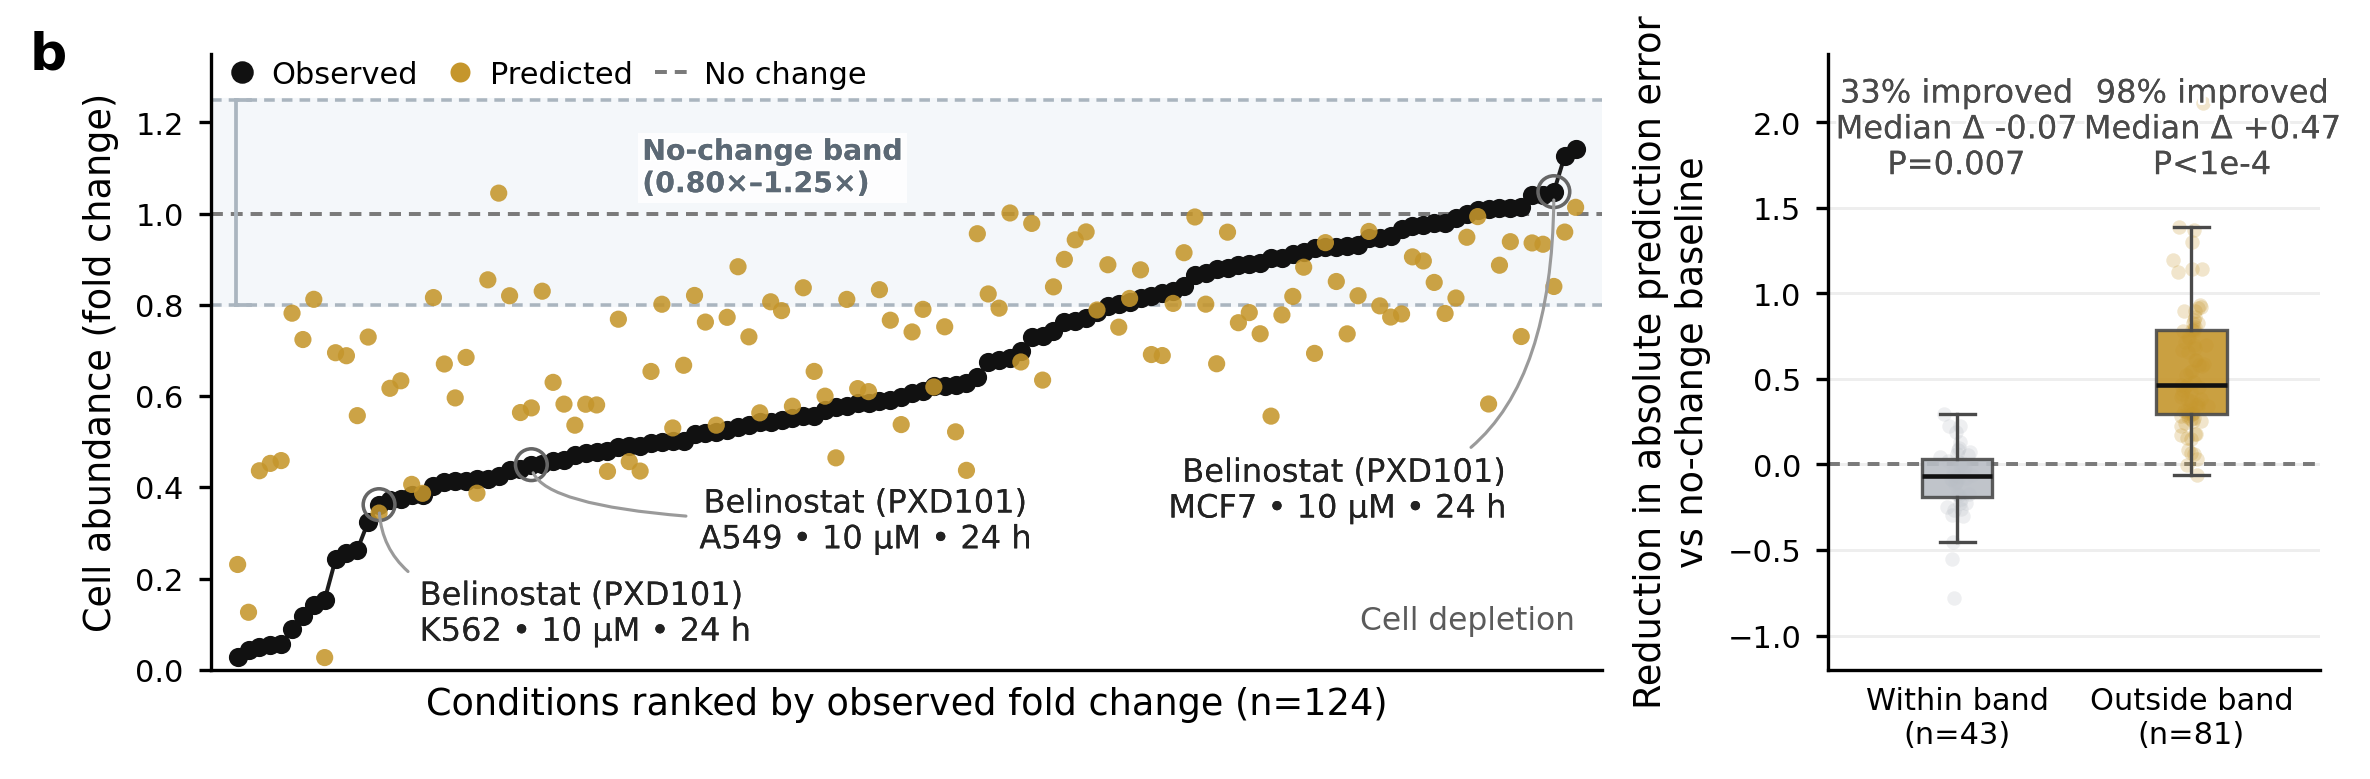

In [34]:
highlight_specs = [
    {
        "perturbation": "Belinostat (PXD101)",
        "cell_line": "K562",
        "dose_value": 10000.0,
        "time": 24.0,
    },
    {
        "perturbation": "Belinostat (PXD101)",
        "cell_line": "A549",
        "dose_value": 10000.0,
        "time": 24.0,
    },
    {
        "perturbation": "Belinostat (PXD101)",
        "cell_line": "MCF7",
        "dose_value": 10000.0,
        "time": 24.0,
    },
]

fig, ax_main, ax_right, plot_df, stats_df = plot_mass_shift_repair_panel_v11_nm(
    df_eval,
    cond_col="cond",
    true_col="true_change",
    pred_col="pred_m_mean",
    shift_threshold=1.25,
    use_log_error=True,
    right_panel="delta_group",
    figsize=(7.9, 3.45),
    dpi=300,
    savepath="figures/Sciplex3/mass_shift_repair_panel_v11_nm.pdf",
    highlight_specs=highlight_specs,
    panel_label="b",
    main_ylim=(0, 1.35),
    right_ylim=(-1.2, 2.4),

    label_positions_axes=[
        (0.15, 0.09),
        (0.47, 0.24),
        (0.93, 0.29),
    ],

    annotation_fontsize=7.7,
    annotation_box_pad=0.16,
    annotation_min_dx=0.22,
    annotation_min_dy=0.15,

    band_label_x_axes=0.31,
    band_label_y_data=1.1,

    right_ylabel=(
        "Reduction in absolute prediction error\n"
        "vs no-change baseline"
    ),

    summary_box_positions=[(0.26, 0.96), (0.78, 0.96)],
    summary_box_fontsize=7.7,
    summary_style="text",

    show_right_panel_note=False,
    verbose_match=True,
    group_label_mode="band",
    show_stems=False,
)

plt.show()


In [ ]:
def plot_two_mse_lines_overlay(df, figsize=(8, 5), logy=False):
    y1 = np.sort(df["mse_baseline"].dropna().values)
    y2 = np.sort(df["mse_pred"].dropna().values)

    n = min(len(y1), len(y2))
    y1 = y1[:n]
    y2 = y2[:n]

    plt.figure(figsize=figsize)
    plt.plot(np.arange(n), y1, label="Baseline MSE", linewidth=2)
    plt.plot(np.arange(n), y2, label="Predicted Mass MSE", linewidth=2)

    plt.xlabel("Condition rank")
    plt.ylabel("MSE")
    plt.title("MSE distribution across conditions")
    if logy:
        plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_two_mse_lines_same_order(df, sort_by="mse_baseline", figsize=(8, 5), logy=False):
    plot_df = df.sort_values(sort_by).reset_index(drop=True)

    plt.figure(figsize=figsize)
    plt.plot(np.arange(len(plot_df)), plot_df["mse_baseline"], label="Baseline MSE", linewidth=2)
    plt.plot(np.arange(len(plot_df)), plot_df["mse_pred"], label="Predicted Mass MSE", linewidth=2)

    plt.xlabel("Condition rank")
    plt.ylabel("MSE")
    plt.title(f"MSE comparison (sorted by {sort_by})")
    if logy:
        plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()


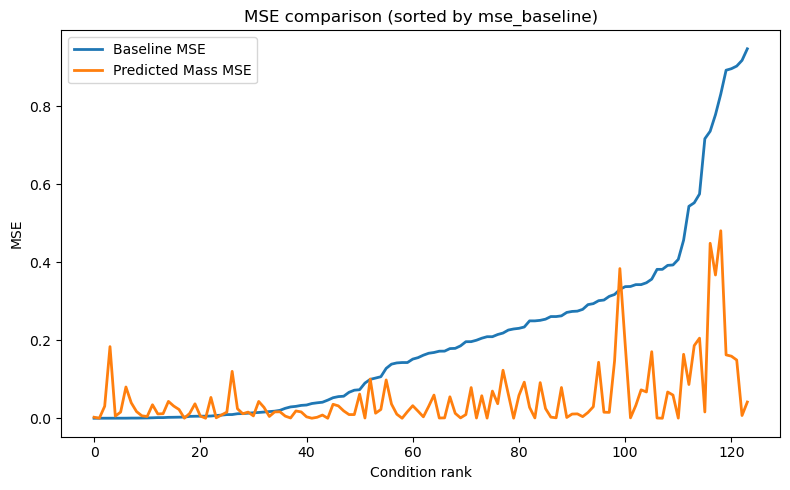

In [15]:

plot_two_mse_lines_same_order(df_eval, sort_by="mse_baseline", logy=False)


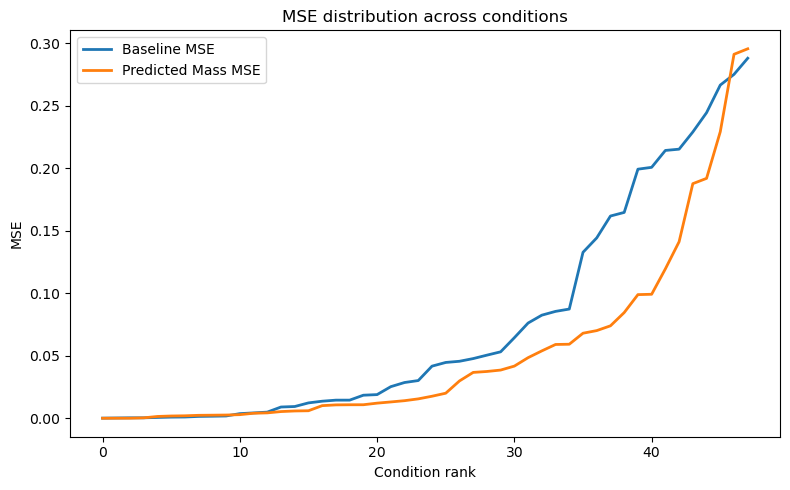

In [42]:
plot_two_mse_lines_overlay(df_eval, logy=False)


In [ ]:
df_eval["mse_diff"] = df_eval["mse_pred"] - df_eval["mse_baseline"]


## legend

In [25]:
from src.evaluate.downstream import *

/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/downstream.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = combined_obs.groupby([condition_combined_key, cell_type_key]).size().unstack(fill_value=0)


=== 细胞绝对数量 ===
cell_type                   B Intermediate/Memory  B Naive  CD4 Memory  \
condition_combined                                                       
('4-1BBL', 'Donor10')                         180      288         999   
('4-1BBL', 'Donor11')                         214      787        1148   
('4-1BBL', 'Donor3')                          408      258        1334   
('4-1BBL', 'Donor5')                          160      207        4007   
('ADSF', 'Donor10')                           182      258         824   
('ADSF', 'Donor11')                           192      698         961   
('ADSF', 'Donor3')                            552      299        1377   
('ADSF', 'Donor5')                            174      226        3603   
('APRIL', 'Donor10')                          118      194         717   
('APRIL', 'Donor11')                          216      631         767   
('APRIL', 'Donor3')                           370      175         899   
('APRIL', 'Donor5')    

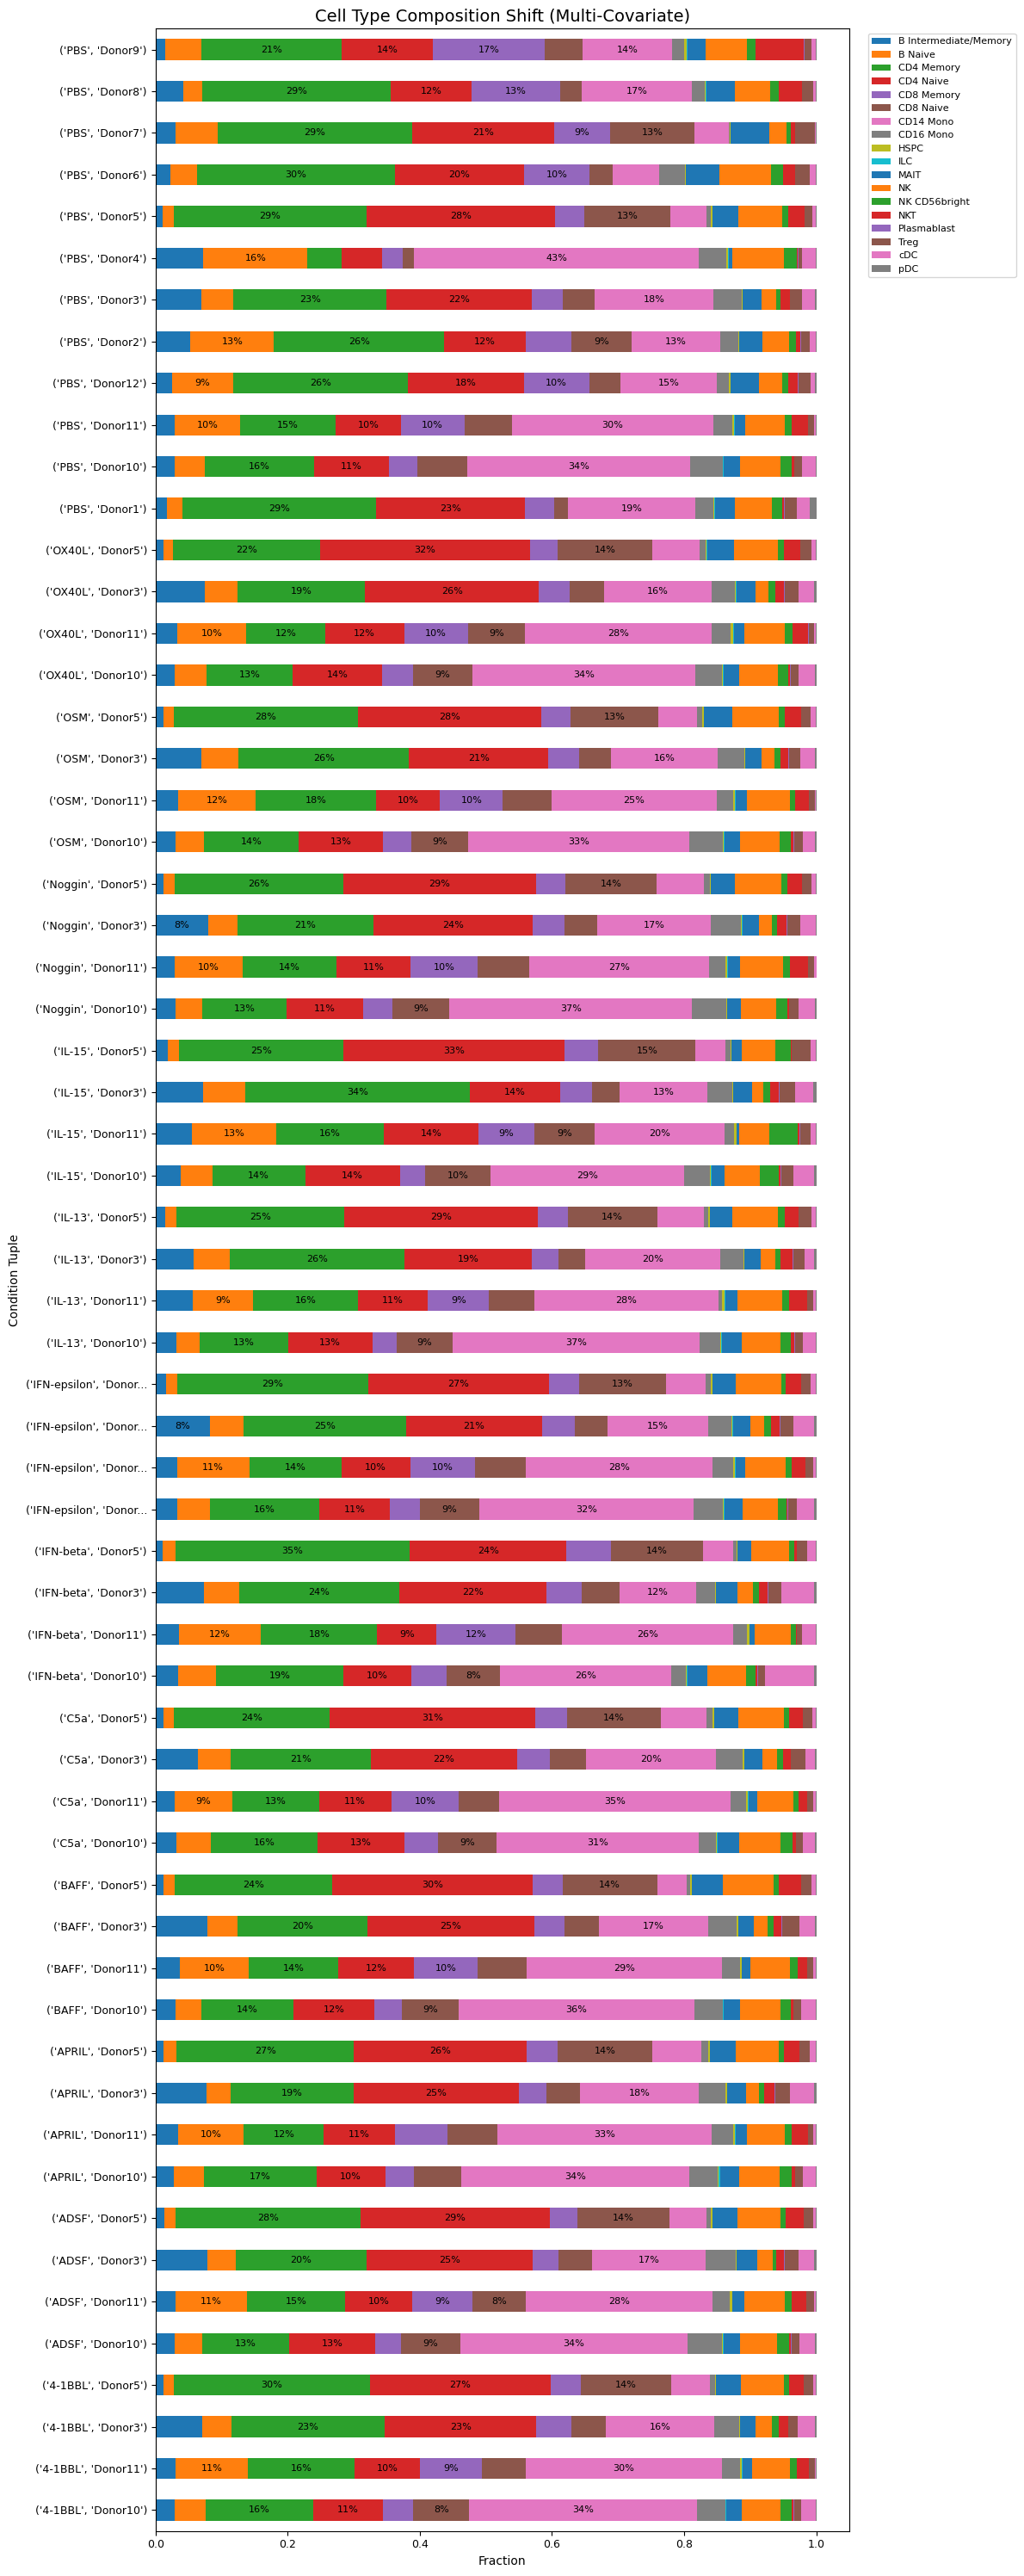

NameError: name 'results_embedding' is not defined

In [34]:
# 1. 检查漂移
counts, fractions = check_population_shift(
    adata_test,
    adata_control,
    condition_combined_key="condition_combined", # 你在 prepare_covariates 阶段生成的列
    cell_type_key="cell_type",
    control_tuple_name="('PBS', 'control')" 
)

# 2. 提取指标与 Tuple 拆解
# 假设你的 rulebook 保存在 adata_treated.uns['global_rulebook']
rulebook = adata_test.uns.get('global_rulebook')

df_metrics = extract_v_and_g_metrics(
    inference_results=results_embedding,
    adata_source=adata_control[indices],
    rulebook=rulebook,
    sample_rep = sample_rep,
    cell_type_key="cell_type",
    n_neighbors=15,
    knn_weights="distance",
    use_groupwise_control=True
)

# 3. 循环绘图 (遍历所有预测的 Tuple 身份)
key_cell_types = [
    "CD14 Mono", "CD4 Memory", "CD4 Naive", "B Naive", "CD8 Memory", 
    "CD8 Naive", "NK", "B Intermediate/Memory", "CD16 Mono", "NKT", 
    "MAIT", "NK CD56bright", "Treg", "HSPC", "cDC", "ILC", "Plasmablast", "pDC"
]

all_predicted_tuples = list(results_embedding.keys())



for tuple_str in all_predicted_tuples:
    plot_predicted_mass_by_celltype(df_metrics, tuple_str, key_cell_types)
    plot_predicted_mass_with_true_label(
        df_metrics=df_metrics, 
        target_tuple_str=tuple_str, 
        target_cell_types=key_cell_types, 
        adata_control=adata_control,
        adata_full=adata_test,
        rulebook=rulebook,
        use_groupwise_control=True,
        condition_combined_key = condition_combined_keys,
        cell_type_key= "cell_type",
        mass_deduct_keys=mass_deduct_keys,
    )


In [ ]:
from src.evaluate import evaluate_all
from src.evaluate.downstream import *

rulebook = adata_train.uns.get('global_rulebook')
if rulebook is None:
    raise ValueError("未找到 global_rulebook，请先确认数据经过了最新版 prepare_covariates 的处理！")

schema = rulebook["condition_tuple_schema"] 


unique_conditions_df = adata_train.obs[schema].drop_duplicates()
wishlist = unique_conditions_df.to_dict(orient='records')

print(f"成功从train中提取了 {len(wishlist)} 个评估愿望 (Wishlist)！")
print(f"示例: {wishlist[0]}") 

# base_condition_key 通常是 schema 的第一个元素（如 'perturbation'）
base_condition_key = schema[0] 


final_df, artifacts = evaluate_all(
    model=model,
    adata_control=adata_control,
    adata_test=adata_train,
    
    wishlist=wishlist,                               # 传入生成的愿望字典列表
    condition_keys=base_condition_key,               # 基础扰动名 (供抽取 Embedding)
    condition_combined_keys=condition_combined_keys,       # 传给下游评估函数作为 pert_key 匹配

    
    control_key=control_key,
    condition_rep_keys=condition_rep_keys,
    sample_rep=sample_rep,
    device=device,
    mass_deduct_keys = mass_deduct_keys,
    n_particles=50000,
    random_seed=42,
    n_steps=50,
    Edistance_sample_num=20000,
    dist_max_cells=20000,
    dist_n_bins=200,
    dist_top_n_degs=50,
    results_save_path=results_save_path,
    scvi_model_load_path=scvi_model_load_path,
    state_model_load_path=state_model_load_path,
    save_each=False,
    save_final=True,
    final_filename=f"final_metrics1_train.csv",
    detailed=True,
    use_groupwise_control=  True,
)

print(final_df)

with open(f"{results_save_path}_train", "wb") as f:
    pickle.dump(artifacts, f)

成功从train中提取了 864 个评估愿望 (Wishlist)！
示例: {'cytokine': '4-1BBL', 'donor': 'Donor1'}
准备为 864 个条件进行推理...


  2%|▏         | 18/864 [00:47<34:19,  2.43s/it] 

In [ ]:
indices = artifacts["indices"]
results_embedding = artifacts["results_embedding"]
results_genes = artifacts["results_genes"]


In [ ]:
# 1. 检查漂移
counts, fractions = check_population_shift(
    adata_train,
    adata_control,
    condition_combined_key="condition_combined", # 你在 prepare_covariates 阶段生成的列
    cell_type_key="cell_type",
    control_tuple_name="('PBS', 'control')" 
)

# 2. 提取指标与 Tuple 拆解
# 假设你的 rulebook 保存在 adata_treated.uns['global_rulebook']
rulebook = adata_train.uns.get('global_rulebook')

df_metrics = extract_v_and_g_metrics(
    inference_results=results_embedding,
    adata_source=adata_control[indices],
    rulebook=rulebook,
    sample_rep = sample_rep,
    cell_type_key="cell_type",
    n_neighbors=15,
    knn_weights="distance",
    use_groupwise_control=True
)

# 3. 循环绘图 (遍历所有预测的 Tuple 身份)
key_cell_types = [
    "CD14 Mono", "CD4 Memory", "CD4 Naive", "B Naive", "CD8 Memory", 
    "CD8 Naive", "NK", "B Intermediate/Memory", "CD16 Mono", "NKT", 
    "MAIT", "NK CD56bright", "Treg", "HSPC", "cDC", "ILC", "Plasmablast", "pDC"
]

all_predicted_tuples = list(results_embedding.keys())



for tuple_str in all_predicted_tuples:
    plot_predicted_mass_by_celltype(df_metrics, tuple_str, key_cell_types)
    plot_predicted_mass_with_true_label(
        df_metrics=df_metrics, 
        target_tuple_str=tuple_str, 
        target_cell_types=key_cell_types, 
        adata_control=adata_control,
        adata_full=adata_train,
        rulebook=rulebook,
        use_groupwise_control=True,
        condition_combined_key = condition_combined_keys,
        cell_type_key= "cell_type",
        mass_deduct_keys=mass_deduct_keys,
    )


In [ ]:
with open(f"{results_save_path}_test", "wb") as f:
    artifacts = pickle.load(f)

In [ ]:
indices = artifacts["indices"]
results_embedding = artifacts["results_embedding"]
results_genes = artifacts["results_genes"]
adata_source = adata_control[indices]

In [ ]:
print(adata_test.obs["cell_type"].value_counts().to_string())

In [ ]:
sc.tl.pca(adata_control, svd_solver='arpack')
sc.pp.neighbors(adata_control, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_control)

In [ ]:
sc.pl.umap(
    adata_control, 
    color='cell_type',      # 按细胞类型着色
    frameon=False,          # 【关键】去掉周围的黑框和坐标轴
    title='',               # 去掉标题（方便后期AI排版）
    legend_fontsize=10,     # 标签字体大小
    size=10,                # 调整点的大小
    save='celltype.pdf'    # 保存为矢量图
)
sc.pl.umap(
    adata_control, 
    vmin=0,
    vmax=6,
    color=[f'FCN1', f'IDO1'], 
)

In [ ]:
adata_true = adata_test[adata_test.obs["cytokine"]=="IL-15"].copy()
adata_pred = results_genes["IL-15"]

In [ ]:
sc.tl.ingest(adata_true, adata_control, embedding_method='umap')
sc.tl.ingest(adata_pred, adata_control, embedding_method='umap')

In [ ]:
adata_control.obs['dataset'] = 'Control'
adata_true.obs['dataset'] = 'True'
adata_pred.obs['dataset'] = 'Pred'

In [ ]:
adata_all = adata_control.concatenate(adata_true, batch_key='dataset',batch_categories=["Control", "True"])

adata_all.obs['plot_color'] = adata_all.obs['dataset'].astype(str)
color_map = {'Control': 'black', 'True': '#1f77b4'} # 也可以用 hex 颜色码

# sc.pl.umap(
#     adata_all, 
#     color='plot_color', 
#     groups=['Control'], # 只高亮 Control
#     palette=color_map,
#     frameon=False,
#     title='Control',
#     size=10 # 根据细胞数调整点大小
# )

sc.pl.umap(
    adata_all, 
    color='plot_color', 
    groups=['True'],    # 只高亮 Test
    palette=color_map,
    frameon=False,
    title='Test Data (Projected)',
    size=10
)
import numpy as np

# 1. 复制一个用于绘图的对象，以免修改原数据
adata_plot = adata_all.copy()

# 2. 将 'Control' 组的这两个基因的表达量设为 NaN (空值)
# 这样 Scanpy 就会把它们识别为缺失值，并涂上 na_color
mask_control = adata_plot.obs['dataset'] == 'Control'

# 注意：如果 .X 是稀疏矩阵，操作稍微麻烦点；如果是 dense 矩阵或已放到 .obs 里可以直接操作
# 这里演示最通用的方法：先把基因值存入 obs，再手动修改
for gene in ['FCN1', 'IDO1']:
    # 获取表达量 (处理稀疏矩阵的情况)
    if hasattr(adata_plot.X, "toarray"):
        values = adata_plot[:, gene].X.toarray().flatten()
    else:
        values = adata_plot[:, gene].X.flatten()
    
    # 存入 obs
    adata_plot.obs[f'plot_{gene}'] = values
    
    # 将 Control 组的值设为 NaN
    adata_plot.obs.loc[mask_control, f'plot_{gene}'] = np.nan

# 3. 绘图
sc.pl.umap(
    adata_plot, 
    color=[f'plot_FCN1', f'plot_IDO1'], 
    na_color='lightgrey', # 这里设置背景色（Control的颜色）
    na_in_legend=False,   # 图例中不显示 NaN
    cmap='viridis',       # Pred 组的颜色映射
    frameon=False,
    vmin=0,
    vmax=6,
    size=10,
    title=['FCN1 (True Only)', 'IDO1 (True Only)']
)


In [ ]:
adata_all = adata_control.concatenate(adata_pred, batch_key='dataset',batch_categories=["Control", "Pred"])

adata_all.obs['plot_color'] = adata_all.obs['dataset'].astype(str)
color_map = {'Control': 'black', 'Pred': '#1f77b4'} # 也可以用 hex 颜色码

sc.pl.umap(
    adata_all, 
    color='plot_color', 
    groups=['Pred'],    # 只高亮 Test
    palette=color_map,
    frameon=False,
    title='Pred Data (Projected)',
    size=10
)


import numpy as np

# 1. 复制一个用于绘图的对象，以免修改原数据
adata_plot = adata_all.copy()

# 2. 将 'Control' 组的这两个基因的表达量设为 NaN (空值)
# 这样 Scanpy 就会把它们识别为缺失值，并涂上 na_color
mask_control = adata_plot.obs['dataset'] == 'Control'

# 注意：如果 .X 是稀疏矩阵，操作稍微麻烦点；如果是 dense 矩阵或已放到 .obs 里可以直接操作
# 这里演示最通用的方法：先把基因值存入 obs，再手动修改
for gene in ['FCN1', 'IDO1']:
    # 获取表达量 (处理稀疏矩阵的情况)
    if hasattr(adata_plot.X, "toarray"):
        values = adata_plot[:, gene].X.toarray().flatten()
    else:
        values = adata_plot[:, gene].X.flatten()
    
    # 存入 obs
    adata_plot.obs[f'plot_{gene}'] = values
    
    # 将 Control 组的值设为 NaN
    adata_plot.obs.loc[mask_control, f'plot_{gene}'] = np.nan

# 3. 绘图
sc.pl.umap(
    adata_plot, 
    color=[f'plot_FCN1', f'plot_IDO1'], 
    na_color='lightgrey', # 这里设置背景色（Control的颜色）
    na_in_legend=False,   # 图例中不显示 NaN
    cmap='viridis',       # Pred 组的颜色映射
    frameon=False,
    vmin=0,
    vmax=6,
    size=10,
    title=['FCN1 (Pred Only)', 'IDO1 (Pred Only)']
)
import numpy as np

# 1. 复制一份用于绘图，避免污染原数据
adata_plot = adata_all.copy()

# 2. 初始化一个新的列用于绘图，先全部设为 NaN (灰色)
adata_plot.obs['plot_mass'] = np.nan

# 3. 找到 Pred 组的位置
mask_pred = adata_plot.obs['dataset'] == 'Pred'

# 4. 将 mass 的值填入 Pred 组对应的位置
# .values 确保赋值时忽略索引名称差异（concat 可能会改索引名）
adata_plot.obs.loc[mask_pred, 'plot_mass'] = adata_pred.obs['mass'].values

# 5. 绘图
sc.pl.umap(
    adata_plot, 
    color='plot_mass', 
    na_color='lightgrey', # Control 组（NaN）显示的颜色
    na_in_legend=False,   # 图例中不显示灰色
    cmap='viridis',       # mass 的色阶
    frameon=False,
    size=10,
    title='Mass on Projected Data'
)

In [ ]:
adata_pred

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def diagnose_mass_prediction(pred_adata, gene_name='CDCA2'):
    mass = pred_adata.obs['mass'].values
    expr = pred_adata[:, gene_name].X.flatten() # 或者是 .layers['counts'] 等
    
    # 1. 打印统计数据
    print(f"=== Mass Statistics for {gene_name} prediction ===")
    print(f"Mean Mass: {np.mean(mass):.4f}")
    print(f"Max  Mass: {np.max(mass):.4f}")
    print(f"Min  Mass: {np.min(mass):.4f}")
    print(f"Std  Mass: {np.std(mass):.4f}")
    
    # 2. 绘图：Mass vs Target Gene Expression
    plt.figure(figsize=(10, 4))
    
    # 子图1: Mass 的直方图
    plt.subplot(1, 2, 1)
    plt.hist(mass, bins=50, color='green', alpha=0.7)
    plt.title("Distribution of Predicted Mass")
    plt.xlabel("Mass")
    plt.ylabel("Count")
    
    # 子图2: Mass vs Expression
    plt.subplot(1, 2, 2)
    plt.scatter(expr, mass, alpha=0.5, s=10, c=mass, cmap='viridis')
    plt.title(f"Mass vs {gene_name} Expression")
    plt.xlabel(f"{gene_name} Expression")
    plt.ylabel("Predicted Mass")
    plt.colorbar(label='Mass')
    
    plt.tight_layout()
    plt.show()

# 运行诊断
for gene in target_genes:
    diagnose_mass_prediction(results_genes[gene], gene)